# Does Borrower Socioeconomic Background Affect Financial Relief in Student Loan Complaints?

# Project 1

## 1.1 Introduction
The Consumer Financial Protection Bureau (CFPB) complaint system is designed to provide consumers with an equal channel to resolve disputes with financial institutions. However, whether complaint outcomes are truly equitable across different socioeconomic groups remains an open question. This project investigates whether borrower socioeconomic background affects the likelihood of receiving financial relief in private student loan complaints filed with the CFPB between 2012 and 2016.

Student loan debt is one of the largest categories of consumer debt in the United States, and it disproportionately affects borrowers from lower-income backgrounds. Looney and Yannelis (2015) show that the increase in student loan defaults is mainly driven by borrowers from for-profit institutions, who tend to come from lower-income families. Mueller and Yannelis (2019) further find that borrower composition and macroeconomic shocks each account for approximately 30% of the rise in defaults, with low-income borrowers more affected in both channels.

When borrowers face problems, they may file complaints with the CFPB. In Hirschman's (1972) framework, filing a complaint is a form of "voice." However, the effectiveness of this voice may depend on the borrower's resources and sophistication. Best and Andreasen (1977) show that higher-status consumers are more likely to achieve satisfactory resolutions. Lusardi and Mitchell (2014) demonstrate that financial literacy varies across socioeconomic groups, while Hastings, Madrian, and Skimmyhorn (2013) review evidence suggesting that financial education alone may be insufficient to close these gaps.

The closest papers to our work are Haendler and Heimer (2021, 2025), who document a socioeconomic gap in financial restitution across all consumer financial products using confidential CFPB data. They find that complaints from low-income and minority zip codes are 30% less likely to receive restitution. In their extended analysis, they find that the gap is mainly driven by consumer engagement and self-advocacy rather than firm-level differences (Haendler & Heimer, 2025). Shin, Kim, and Shin (2026) provide further evidence that how a complaint is written matters, finding that consumers using large language models to draft complaints increase their probability of relief by 6.9 percentage points.

On the firm side, Darolia and Sullivan (2020) show that student loan servicers face complex incentives that may not align with borrower welfare, and Kim, Vickery, Scharlemann, and Lee (2024) find that servicer characteristics such as size and liquidity affect the provision of forbearance. This connects to the discrimination literature: Phelps (1972) introduces statistical discrimination theory, Bohren, Imas, and Rosenberg (2019) show that discrimination can be driven by dynamically evolving biased beliefs, and Li (2023) demonstrates that CFPB complaint narrative disclosure reduced racial disparities in mortgage lending.

Our project contributes to this literature in three ways. First, we focus specifically on private student loans, a market with distinct borrower demographics. Second, we decompose relief into monetary and non-monetary components. Third, our analysis of complaint ambiguity provides evidence that socioeconomic disparities are concentrated in complaints where firms have more discretion, consistent with both statistical discrimination and the consumer sophistication channel.

## 1.2 Data Loading

### 1.2.1 Data Sources
This study combines two datasets. The primary dataset is the CFPB Consumer Complaint Database, containing individual complaint records including the issue type, firm response, and borrower zip code. We focus on private student loan complaints filed between 2012 and 2016, excluding debt collectors and law firms, yielding 14,492 complaints against 59 firms. 

We merge this with zip code-level socioeconomic data from the 2014 American Community Survey (ACS) five-year estimates, matching approximately 83% of complaints for an analytical sample of 12,028 observations.

### 1.2.2 Research Design & Variable Definitions
The empirical framework links borrower socioeconomic conditions to complaint resolution outcomes through the composition of complaint issue types. 

The dependent variable, Financial Relief, is a binary indicator equal to one if the firm's response was "Closed with monetary relief" or "Closed with non-monetary relief," and zero otherwise. 

The key explanatory variables are four zip code-level socioeconomic characteristics from the ACS, merged to complaints using borrower zip codes. Log median household income captures overall economic well-being, with the log transformation accounting for the right-skewed income distribution. Poverty rate measures the share of residents below the federal poverty line, reflecting local economic hardship. Unemployment rate captures labor market conditions that affect borrowers' ability to manage repayment. The share of residents with a bachelor's degree or higher serves as a proxy for financial literacy and the capacity to navigate complex complaint processes. We also include firm type, distinguishing banks, non-bank lenders, and state or non-profit servicers, to control for institutional differences in servicing practices.

The proposed mechanism is complaint issue type, which we hypothesize is shaped by local socioeconomic conditions. We consider five categories: Dealing with my lender or servicer, Repaying your loan, Problems when you are unable to pay, Getting a loan, and Can't repay my loan (reference category). Since different issue types vary in their difficulty of resolution, this channel provides a pathway through which socioeconomic characteristics may indirectly affect the likelihood of receiving relief.

### 1.2.3 Data Loading

Cleaning the original dataset:

In [44]:
import pandas as pd

# Load the raw dataset
df_raw = pd.read_csv('consumer_complaints.csv', low_memory=False)

# Extract only student loan complaints for analysis
df = df_raw[df_raw['product'] == 'Student loan']

# 1. Clean 'company_response_to_consumer'
# Replace 'Closed with relief' with 'Closed with non-monetary relief' first
df['company_response_to_consumer'] = df['company_response_to_consumer'].replace(
    'Closed with relief', 'Closed with non-monetary relief'
)

# Keep only the 4 specified clean categories
valid_responses = [
    'Closed with explanation', 
    'Closed with monetary relief', 
    'Closed with non-monetary relief', 
    'Closed without relief'
]
df = df[df['company_response_to_consumer'].isin(valid_responses)]

# 2. Drop specified columns
columns_to_drop = [
    'company_public_response', 
    'consumer_consent_provided'
]
# We use a list comprehension to only drop columns that exist in the dataframe to avoid errors
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 3. Clean 'company' column for Brazos
df.loc[df['company'].str.contains('Brazos', case=False, na=False), 'company'] = 'Brazos higher Education Servicing'

# 4. Save the cleaned dataset to a new CSV file without the row indices.
df.to_csv('df.csv', index=False)

Excluding firms that are debt collectors:

In [45]:
firms = pd.read_csv('Firms_characteristics.csv')

# Ensure the merge column is named consistently (firms dataset has 'Company' with capital C)
if 'Company' in firms.columns:
    firms = firms.rename(columns={'Company': 'company_firm'})

# Create a normalized lowercase merge key to prevent match failures due to case sensitivity
df['merge_key'] = df['company'].str.lower().str.strip()
firms['merge_key'] = firms['company_firm'].str.lower().str.strip()

# Perform an inner join on the merge key
# An inner join drops any companies from 'df' that are not in 'firms'
merged_df = pd.merge(df, firms, on='merge_key', how='inner')

# Drop the temporary merge key and duplicate company column
merged_df = merged_df.drop(columns=['merge_key', 'company_firm'])

# Save the cleaned and merged dataset to a new CSV file
merged_df.to_csv('df.csv', index=False)

Getting local socioeconomic characteristics from ACS dataset:

In [46]:
import pandas as pd

# 1. Read the two CSV files. 
# Use header=1 to set the second row (the descriptive long names) as DataFrame column names.
# Note: Ensure the CSV files are in the same directory as this script.
df_dp03 = pd.read_csv('ACSDP5Y2014.DP03-Data.csv', header=1)
df_s1501 = pd.read_csv('ACSST5Y2014.S1501-Data.csv', header=1, low_memory=False)  # low_memory=False to avoid dtype warnings

# 2. Define the columns to extract from the DP03 dataset.
# This includes the primary key 'Geography' and 'Geographic Area Name' for merging and identification.
dp03_cols = [
    'Geography', 
    'Geographic Area Name',
    'Estimate!!INCOME AND BENEFITS (IN 2014 INFLATION-ADJUSTED DOLLARS)!!Total households!!Median household income (dollars)',
    'Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people',
    'Percent!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Unemployed'
]

# 3. Define the columns to extract from the S1501 dataset.
s1501_cols = [
    'Geography',
    "Total!!Estimate!!Percent bachelor's degree or higher"
]

# 4. Filter the DataFrames to keep only the selected columns.
df_dp03_filtered = df_dp03[dp03_cols]
df_s1501_filtered = df_s1501[s1501_cols]

# 5. Merge the two DataFrames into a new table named 'local_socioeconomics'.
# We use 'Geography' as the key to perform an inner join.
local_socioeconomics = pd.merge(df_dp03_filtered, df_s1501_filtered, on='Geography', how='inner')

# Rename the columns to make them shorter and more readable.

local_socioeconomics = local_socioeconomics.rename(columns={
    'Geographic Area Name': 'Name',
    'Estimate!!INCOME AND BENEFITS (IN 2014 INFLATION-ADJUSTED DOLLARS)!!Total households!!Median household income (dollars)': 'Median Household Income',
    'Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people': 'Poverty Rate (%)',
    'Percent!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Unemployed': 'Unemployment Rate (%)',
    "Total!!Estimate!!Percent bachelor's degree or higher": "Bachelor's Degree or Higher (%)"
})

# 6. Save the merged DataFrame to a new CSV file without the row indices.
local_socioeconomics.to_csv('local_socioeconomics.csv', index=False)

Merging complaint dataset with local socioeconomic charateristics:

In [47]:
import pandas as pd

# 1. Load the two datasets
# Read the main complaints dataframe
df = pd.read_csv('df.csv')

# Read the socioeconomics dataframe
socio = pd.read_csv('local_socioeconomics.csv')

# 2. Clean and prepare the merge keys
# The 'Name' column in socio has the format "ZCTA5 12345". 
# We need to extract just the 5-digit zip code.
# We split by space and take the second part.
socio['zipcode'] = socio['Name'].str.split(' ').str[1]

# Ensure both zip code columns are treated as strings to avoid type mismatch
# Also pad with leading zeros in case any zip codes lost them during loading
df['zipcode'] = df['zipcode'].astype(str).str.zfill(5)
socio['zipcode'] = socio['zipcode'].astype(str).str.zfill(5)

# 3. Merge the datasets
# We perform a left merge so we don't lose any rows from the main 'df' 
# if a zipcode is missing in the socioeconomics dataset.
merged_df = pd.merge(df, socio, on='zipcode', how='left')

# 4. Optional: Drop the redundant 'Geography' and 'Name' columns if you don't need them
merged_df = merged_df.drop(columns=['Geography', 'Name'])

# 5. Save the merged dataset to a new CSV file
merged_df.to_csv('df.csv', index=False)

Creating new variables based on original variables:

In [49]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('df.csv')

# 2. Format date_received to datetime
# Note: errors='coerce' will turn invalid dates into NaT (Not a Time)
df['date_received'] = pd.to_datetime(df['date_received'], errors='coerce')

# 3. Create 'year' variable
df['year'] = df['date_received'].dt.year

# 4. Create 'any_relief' variable
# Assumption: In CFPB data, relief usually means "Closed with monetary relief" 
# or "Closed with non-monetary relief". We exclude "Closed without relief".
relief_categories = ['Closed with monetary relief', 'Closed with non-monetary relief']
df['any_relief'] = df['company_response_to_consumer'].isin(relief_categories).astype(int)
df['no_relief'] = (df['company_response_to_consumer'] == 'Closed without relief').astype(int)
df['explanation_only'] = (df['company_response_to_consumer'] == 'Closed with explanation').astype(int)

# 5. Create 'monetary_relief' variable
# Assumption: Only exactly "Closed with monetary relief"
df['monetary_relief'] = (df['company_response_to_consumer'] == 'Closed with monetary relief').astype(int)
df['nonmonetary_relief'] = (df['company_response_to_consumer'] == 'Closed with non-monetary relief').astype(int)

# 6. Create 'issue type dummies'
# This creates binary columns for each unique value in the 'issue' column.
# We add a prefix 'issue_' so they are easy to identify in the dataframe.
issue_dummies = pd.get_dummies(df['issue'], prefix='issue', dtype=int)
df = pd.concat([df, issue_dummies], axis=1)
df = df.drop(columns=["issue_Can't repay my loan"])

# 7. Create 'log_income' variable
# First, ensure income is numeric. Then safely apply log transformation.
# We replace 0 with NaN before applying log to avoid -inf results.
df['Median Household Income'] = pd.to_numeric(df['Median Household Income'], errors='coerce')
df['log_income'] = np.log(df['Median Household Income'].replace(0, np.nan))

# 8. Create 'has_narrative' variable
# 1 if consumer_complaint_narrative has text, 0 if it is NaN/null
df['has_narrative'] = df['consumer_complaint_narrative'].notna().astype(int)

# 9. Create 'web_submit' variable
# Assumption: Submitted via 'Web'
df['web_submit'] = (df['submitted_via'] == 'Web').astype(int)

# 10. Create 'is_servicemember' variable
# Assumption: The 'tags' column contains the word 'Servicemember'
df['is_servicemember'] = df['tags'].str.contains('Servicemember', case=False, na=False).astype(int)

# 11. Create 'is_older' variable
# Assumption: The 'tags' column contains the phrase 'Older American'
df['is_older'] = df['tags'].str.contains('Older American', case=False, na=False).astype(int)

# Save the updated dataframe to a new CSV
df.to_csv('df.csv', index=False)

## 1.3 Summary Statistic Table

### 1.3.1 Summary Statistics (Table 1)

In [50]:
df_stats = df.dropna(subset=['Median Household Income']).copy()
df_stats = df_stats.loc[:, ~df_stats.columns.duplicated()]

summary_vars = ['any_relief', 'monetary_relief', 'nonmonetary_relief',
                'Median Household Income', 'Poverty Rate (%)', 
                'Unemployment Rate (%)', "Bachelor's Degree or Higher (%)",
                'issue_Repaying your loan', 
                'issue_Dealing with my lender or servicer',
                'issue_Getting a loan',
                'issue_Problems when you are unable to pay']

for col in summary_vars:
    df_stats[col] = pd.to_numeric(df_stats[col], errors='coerce')

table1 = df_stats[summary_vars].describe().T[['count','mean','std','min','25%','50%','75%','max']].round(4)
table1.to_csv('table1_summary_statistics.csv', index=True)
display(table1)

,count,mean,std,min,25%,50%,75%,max
any_relief,12028.0,0.1766,0.3813,0.0,0.0,0.0,0.0,1.0
monetary_relief,12028.0,0.0704,0.2559,0.0,0.0,0.0,0.0,1.0
nonmonetary_relief,12028.0,0.1062,0.3081,0.0,0.0,0.0,0.0,1.0
Median Household Income,12028.0,62286.7739,23566.6196,9075.0,45268.0,57967.0,75410.0,214688.0
Poverty Rate (%),12028.0,14.1555,8.9365,0.0,7.5,12.0,18.7,83.9
Unemployment Rate (%),12028.0,5.8061,2.2742,0.0,4.2,5.4,7.0,20.6
Bachelor's Degree or Higher (%),12028.0,34.5955,17.5288,0.0,21.0,31.0,45.5,92.8
issue_Repaying your loan,12028.0,0.3000,0.4583,0.0,0.0,0.0,1.0,1.0
issue_Dealing with my lender or servicer,12028.0,0.3047,0.4603,0.0,0.0,0.0,1.0,1.0
issue_Getting a loan,12028.0,0.0307,0.1725,0.0,0.0,0.0,0.0,1.0


The sample includes 12,028 complaints with complete socioeconomic data. 

- Approximately 17.7% of complaints result in some form of financial relief, with non-monetary relief (10.6%) being more common than monetary relief (7.0%). 

- The average median household income across borrower zip codes is 62,287 dollars, with substantial variation (standard deviation of 23,567 dollars), ranging from 9,075 dollars to over 214,000 dollars. 

- The average poverty rate is about 14.2% and the average share of residents with a bachelor's degree is 34.6%. 

- Among complaint types, "Dealing with my lender or servicer" is the most common issue, while "Getting a loan" is the least frequent. 

This variation in both socioeconomic conditions and complaint types provides sufficient scope to examine whether borrower background is associated with complaint resolution outcomes.


### 1.3.2 Subgroup Analysis (Table 2)

In [51]:
df_stats['Median Household Income'] = pd.to_numeric(df_stats['Median Household Income'], errors='coerce')
df_stats['Poverty Rate (%)'] = pd.to_numeric(df_stats['Poverty Rate (%)'], errors='coerce')
df_stats['Unemployment Rate (%)'] = pd.to_numeric(df_stats['Unemployment Rate (%)'], errors='coerce')
df_stats["Bachelor's Degree or Higher (%)"] = pd.to_numeric(df_stats["Bachelor's Degree or Higher (%)"], errors='coerce')

df_stats['income_quartile'] = pd.qcut(df_stats['Median Household Income'], 4, 
                                       labels=['Q1_Low','Q2','Q3','Q4_High'])

table2 = df_stats.groupby('income_quartile').agg(
    N=('any_relief','count'),
    Median_Income=('Median Household Income','mean'),
    Relief_Rate=('any_relief','mean'),
    Monetary_Relief=('monetary_relief','mean'),
    Nonmonetary_Relief=('nonmonetary_relief','mean'),
    Poverty_Rate=('Poverty Rate (%)','mean'),
    Bachelors_Pct=("Bachelor's Degree or Higher (%)",'mean'),
    Unemployment=('Unemployment Rate (%)','mean')
).round(4)
table2.to_csv('table2_relief_by_income_quartile.csv', index=True)
display(table2)

,N,Median_Income,Relief_Rate,Monetary_Relief,Nonmonetary_Relief,Poverty_Rate,Bachelors_Pct,Unemployment
income_quartile,,,,,,,,
Q1_Low,3007,37026.8487,0.1610,0.0635,0.0974,25.1714,21.2739,7.4658
Q2,3007,51375.8577,0.1679,0.0635,0.1044,14.9940,28.1758,5.9918
Q3,3011,66089.7081,0.1797,0.0747,0.1049,10.0189,37.2376,5.2459
Q4_High,3003,94692.7296,0.1978,0.0799,0.1179,6.4331,51.7140,4.5199


We can observe that borrowers from higher-income zip codes receive financial relief at notably higher rates. 

The relief rate increases monotonically from 16.1% in the lowest income quartile to 19.8% in the highest, a gap of 3.7 percentage points. Monetary relief shows a similar pattern, rising from 6.4% to 8.0%. This disparity is striking given that borrowers in the lowest quartile face substantially more economic hardship: their average poverty rate is 25.2% compared to 6.4% in the highest quartile, and only 21.3% hold a bachelor's degree versus 51.7%. 

These patterns suggest that the most financially vulnerable borrowers are also the least likely to receive relief, raising questions about whether the nature of their complaints or other factors drive this gap.

### 1.3.3 Subgroup Analysis (Table 3)

In [387]:
df_stats['education_quartile'] = pd.qcut(df_stats["Bachelor's Degree or Higher (%)"], 4, 
                                          labels=['Q1_Low_Edu','Q2','Q3','Q4_High_Edu'])

table3 = df_stats.groupby('education_quartile').agg(
    N=('any_relief','count'),
    Bachelors_Pct=("Bachelor's Degree or Higher (%)",'mean'),
    Relief_Rate=('any_relief','mean'),
    Monetary_Relief=('monetary_relief','mean'),
    Nonmonetary_Relief=('nonmonetary_relief','mean'),
    Median_Income=('Median Household Income','mean'),
    Poverty_Rate=('Poverty Rate (%)','mean')
).round(4)
display(table3)

,N,Bachelors_Pct,Relief_Rate,Monetary_Relief,Nonmonetary_Relief,Median_Income,Poverty_Rate
education_quartile,,,,,,,
Q1_Low_Edu,3029,15.2322,0.1578,0.0617,0.0961,43402.8029,20.6345
Q2,2999,25.9679,0.1727,0.0690,0.1037,55173.5622,14.5423
Q3,2994,37.8371,0.1794,0.0688,0.1106,66399.2281,11.3461
Q4_High_Edu,3006,59.4860,0.1966,0.0822,0.1144,84315.8430,10.0392


The education quartile analysis reveals a similar pattern. 

Overall relief rates increase from 15.8% in the least-educated areas to 19.7% in the most-educated, a gap of 3.9 percentage points. Both monetary and non-monetary relief increase steadily across education quartiles. 

Whether education and income capture different dimensions of advantage will be examined in the regression analysis.

## 1.4 Visual Analysis

### 1.4.1 Figure 1: Distribution of Median Household Income

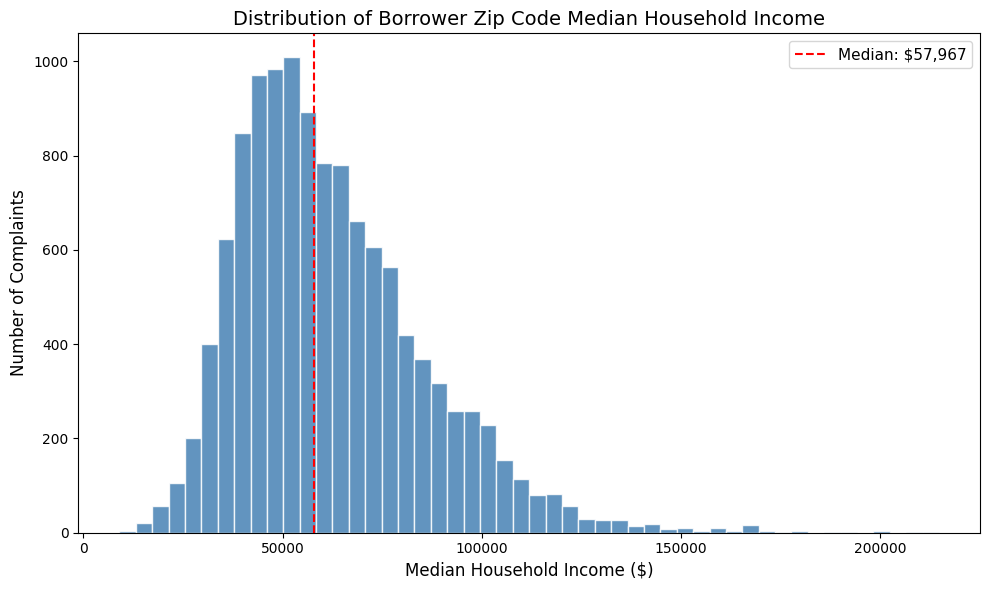

In [388]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Plot 1: Histogram - Distribution of Median Household Income
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_stats['Median Household Income'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Median Household Income ($)', fontsize=12)
ax.set_ylabel('Number of Complaints', fontsize=12)
ax.set_title('Distribution of Borrower Zip Code Median Household Income', fontsize=14)
ax.axvline(df_stats['Median Household Income'].median(), color='red', linestyle='--', linewidth=1.5, label=f"Median: ${df_stats['Median Household Income'].median():,.0f}")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The distribution of borrower zip code median household income is right-skewed, with a median of 57,967 dollars. 

The majority of complaints originate from zip codes with median incomes between 30,000 and 80,000 dollars, while a smaller number come from wealthier areas exceeding 100,000 dollars. This right skew motivates the use of log-transformed income in the regression analysis.

### 1.4.2 Figure 2: Relief Rate by Income Quartile (Core Story)

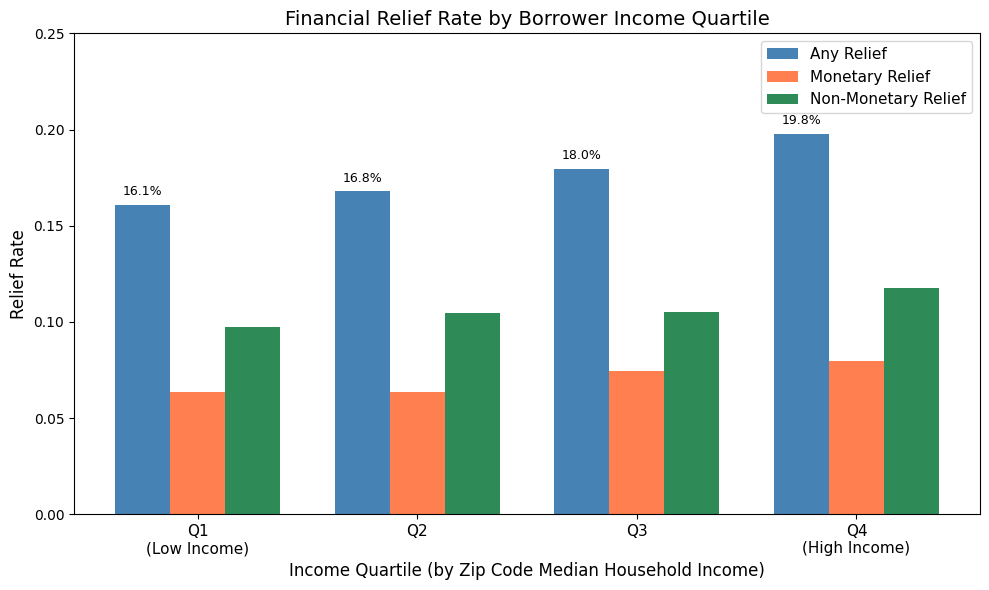

In [30]:
# ============================================
# Plot 2: Bar Chart - Relief Rate by Income Quartile (Core Story)
# ============================================
df_stats['income_quartile'] = pd.qcut(df_stats['Median Household Income'], 4, 
                                       labels=['Q1\n(Low Income)', 'Q2', 'Q3', 'Q4\n(High Income)'])

quartile_relief = df_stats.groupby('income_quartile')[['any_relief','monetary_relief','nonmonetary_relief']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)
width = 0.25
ax.bar(x - width, quartile_relief['any_relief'], width, label='Any Relief', color='steelblue')
ax.bar(x, quartile_relief['monetary_relief'], width, label='Monetary Relief', color='coral')
ax.bar(x + width, quartile_relief['nonmonetary_relief'], width, label='Non-Monetary Relief', color='seagreen')
ax.set_xlabel('Income Quartile (by Zip Code Median Household Income)', fontsize=12)
ax.set_ylabel('Relief Rate', fontsize=12)
ax.set_title('Financial Relief Rate by Borrower Income Quartile', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(quartile_relief.index, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.25)
for i, v in enumerate(quartile_relief['any_relief']):
    ax.text(i - width, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('relief_by_income_quartile.png', dpi=300, bbox_inches='tight')
plt.show()

This figure presents the central descriptive finding of this paper. 

Financial relief rates increase monotonically across income quartiles, from 16.1% in Q1 to 19.8% in Q4, a gap of 3.7 percentage points. Both monetary and non-monetary relief follow this upward pattern. Whether this disparity reflects differences in the nature of complaints filed or other factors will be examined in the regression analysis.


### 1.4.3 Figure 3: Bachelor's Degree % vs Relief Rate

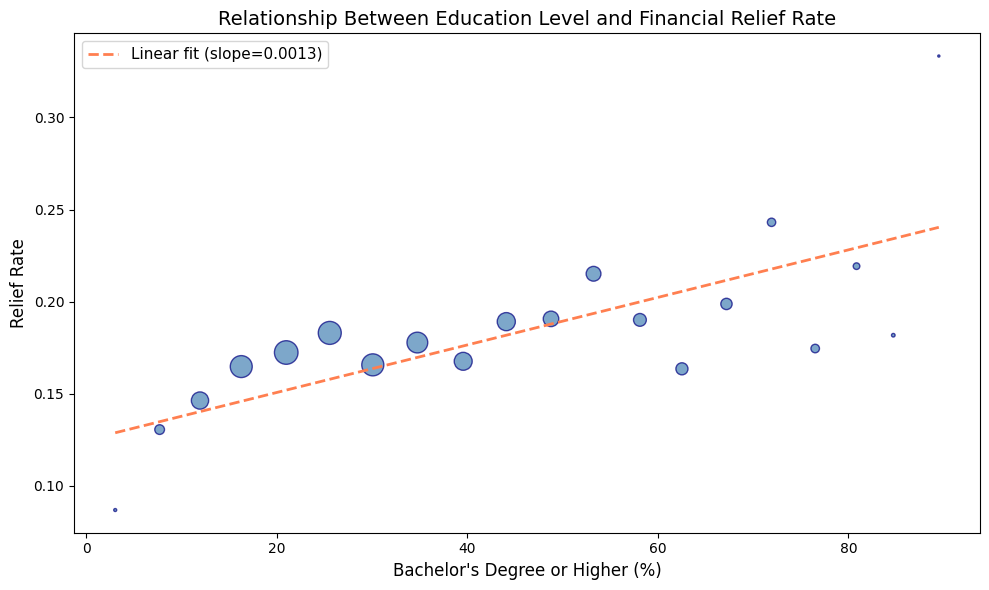

In [ ]:
# ============================================
# Plot 3: Binned Scatter - Bachelor's Degree % vs Relief Rate
# ============================================
df_stats['bachelors_bin'] = pd.cut(df_stats["Bachelor's Degree or Higher (%)"], bins=20)
binned = df_stats.groupby('bachelors_bin').agg(
    bachelors_mid=("Bachelor's Degree or Higher (%)", 'mean'),
    relief_rate=('any_relief', 'mean'),
    n=('any_relief', 'count')
).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(binned['bachelors_mid'], binned['relief_rate'], 
                     s=binned['n']/5, alpha=0.7, color='steelblue', edgecolor='navy')
z = np.polyfit(binned['bachelors_mid'], binned['relief_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(binned['bachelors_mid'].min(), binned['bachelors_mid'].max(), 100)
ax.plot(x_line, p(x_line), color='coral', linewidth=2, linestyle='--', label=f'Linear fit (slope={z[0]:.4f})')
ax.set_xlabel("Bachelor's Degree or Higher (%)", fontsize=12)
ax.set_ylabel('Relief Rate', fontsize=12)
ax.set_title("Relationship Between Education Level and Financial Relief Rate", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

This binned scatter plot shows a clear positive association between area-level education and financial relief rates. 

Zip codes where fewer than 10% of residents hold a bachelor's degree have relief rates below 15%, while those with over 50% college-educated residents see relief rates approaching 20%. The fitted line has a positive slope of 0.0013. The dispersion around the trend line suggests that education alone does not fully determine relief outcomes, motivating the inclusion of additional controls in the regression analysis.

### 1.4.4 Figure 4: Relief Rate by Issue Type

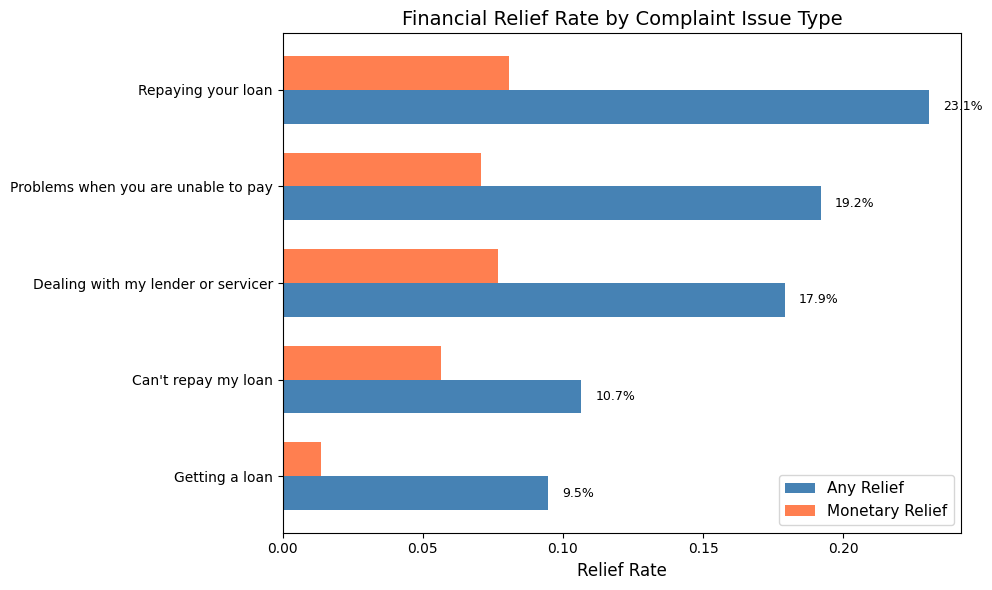

In [33]:
# ============================================
# Plot 4: Grouped Bar Chart - Relief Rate by Issue Type (Z -> Y)
# ============================================
issue_relief = df_stats.groupby('issue')[['any_relief','monetary_relief']].mean().sort_values('any_relief', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(issue_relief))
height = 0.35
ax.barh(y_pos - height/2, issue_relief['any_relief'], height, label='Any Relief', color='steelblue')
ax.barh(y_pos + height/2, issue_relief['monetary_relief'], height, label='Monetary Relief', color='coral')
ax.set_yticks(y_pos)
ax.set_yticklabels(issue_relief.index, fontsize=10)
ax.set_xlabel('Relief Rate', fontsize=12)
ax.set_title('Financial Relief Rate by Complaint Issue Type', fontsize=14)
ax.legend(fontsize=11)
for i, v in enumerate(issue_relief['any_relief']):
    ax.text(v + 0.005, i - height/2, f'{v:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('relief_by_issue_type.png', dpi=300, bbox_inches='tight')
plt.show()

This figure illustrates the proposed mechanism (Z): complaint issue type is strongly associated with relief. 

"Repaying your loan" complaints have the highest relief rate at 23.1%, more than double that of "Can't repay my loan" (10.7%). This is economically intuitive as repayment issues such as billing errors are specific, verifiable problems that firms can readily correct. In contrast, complaints about inability to repay reflect broader financial hardship that firms have limited ability to resolve. If lower-income borrowers disproportionately file "can't repay" complaints, this compositional difference could partially explain why they receive less relief.

### 1.4.5 Figure 5: Distribution of Median Household Income by Complaint Outcome

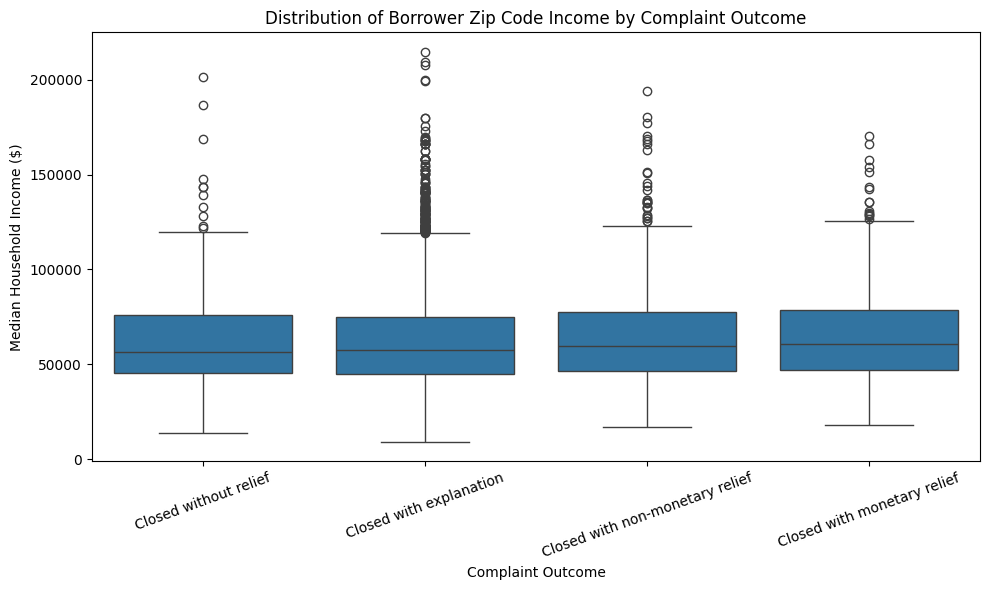

In [ ]:
# ============================================
# Plot 5: Box Plot - Distribution of Median Household Income by Complaint Outcome (Z -> Y)
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = df.dropna(subset=['Median Household Income', 'company_response_to_consumer']).copy()
df_plot['Median Household Income'] = pd.to_numeric(df_plot['Median Household Income'], errors='coerce')

order = [
    'Closed without relief',
    'Closed with explanation',
    'Closed with non-monetary relief',
    'Closed with monetary relief'
]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot,
    x='company_response_to_consumer',
    y='Median Household Income',
    order=order
)
plt.xticks(rotation=20)
plt.xlabel('Complaint Outcome')
plt.ylabel('Median Household Income ($)')
plt.title('Distribution of Borrower Zip Code Income by Complaint Outcome')
plt.tight_layout()
plt.show()

This box plot examines whether borrowers from higher-income areas are more likely to receive relief. 

The distributions across all four outcome categories are highly overlapping, and the median income increases only slightly from "closed without relief" to "closed with monetary relief." This suggests that the raw relationship between income and outcomes is weak, motivating regression analysis to control for complaint type and firm characteristics.

# Project 2

## 2.1 The Message

**THE MESSAGE**: Borrowers from lower-income and less-educated zip codes are significantly less likely to receive financial relief in student loan complaints, and relief rates increase monotonically from 16.1% in the lowest income quartile to 19.8% in the highest. This pattern persists after controlling for complaint issue type, firm type, and year, suggesting that the gap is not driven solely by differences in complaint characteristics.

    income_quartile  Raw Relief Rate  Issue-Type Standardized Relief Rate
0   Q1 (Low Income)         0.160958                             0.164126
1                Q2         0.167941                             0.169478
2                Q3         0.179675                             0.179787
3  Q4 (High Income)         0.197802                             0.193064


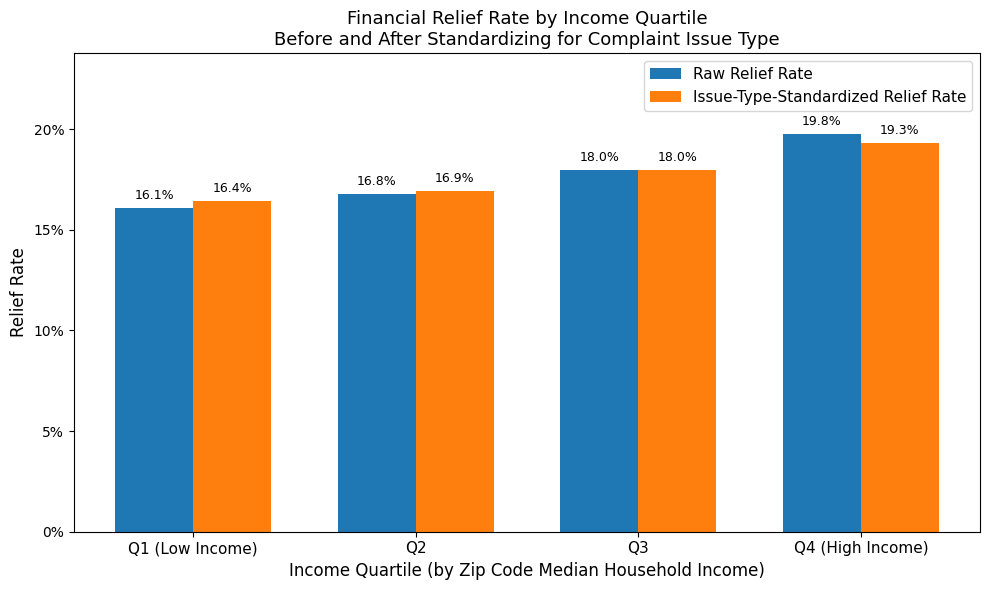

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_csv('df.csv').copy()

# -----------------------------
# 2. Create income quartiles
# -----------------------------
df['income_quartile'] = pd.qcut(
    df['Median Household Income'],
    4,
    labels=['Q1 (Low Income)', 'Q2', 'Q3', 'Q4 (High Income)']
)

# -----------------------------
# 3. Define issue type column
# Replace 'issue' with your actual issue-type column name if needed
# -----------------------------
issue_col = 'issue'

# Keep only rows with non-missing values
df = df.dropna(subset=['income_quartile', issue_col, 'any_relief'])

# -----------------------------
# 4. Compute overall issue-type distribution
# This is the common distribution used to "control for" issue type
# -----------------------------
issue_weights = df[issue_col].value_counts(normalize=True).sort_index()

# -----------------------------
# 5. Compute relief rate within each income quartile × issue type cell
# -----------------------------
cell_rates = (
    df.groupby(['income_quartile', issue_col], observed=False)['any_relief']
      .mean()
      .unstack()
)

# Make sure columns align with issue_weights
cell_rates = cell_rates.reindex(columns=issue_weights.index)

# -----------------------------
# 6. Standardize:
# For each income quartile, reweight its issue-specific relief rates
# by the overall issue distribution
# -----------------------------
standardized_rates = cell_rates.mul(issue_weights, axis=1).sum(axis=1)

# Also compute raw rates for comparison if you want
raw_rates = df.groupby('income_quartile', observed=False)['any_relief'].mean()

# -----------------------------
# 7. Put results into a table
# -----------------------------
plot_df = pd.DataFrame({
    'Raw Relief Rate': raw_rates,
    'Issue-Type Standardized Relief Rate': standardized_rates
}).reset_index()

print(plot_df)

# -----------------------------
# 8. Plot
# -----------------------------
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, plot_df['Raw Relief Rate'], width, label='Raw Relief Rate')
bars2 = ax.bar(x + width/2, plot_df['Issue-Type Standardized Relief Rate'], width,
               label='Issue-Type-Standardized Relief Rate')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['income_quartile'], fontsize=11)
ax.set_xlabel('Income Quartile (by Zip Code Median Household Income)', fontsize=12)
ax.set_ylabel('Relief Rate', fontsize=12)
ax.set_title('Financial Relief Rate by Income Quartile\nBefore and After Standardizing for Complaint Issue Type', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

ymax = max(plot_df['Raw Relief Rate'].max(), plot_df['Issue-Type Standardized Relief Rate'].max())
ax.set_ylim(0, ymax + 0.04)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003, f'{h:.1%}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

The standardized relief rate is constructed by first computing the relief rate within each income quartile × issue type cell, and then taking a weighted average of these rates using the overall issue type distribution in the full sample. In other words, for each income quartile, we ask: what would the relief rate be if this group had the same mix of complaint issues as the overall population?

Comparing the raw and standardized rates, the upward gradient in relief from Q1 to Q4 remains largely unchanged. This indicates that differences in complaint composition across income groups are not the primary driver of the observed pattern, and that higher-income areas still exhibit higher relief rates even when holding issue types constant.

## 2.2 Maps and Interpretations

We aggregate complaint data to the state level for geographic visualization. ZIP-code aggregation was considered but abandoned: fewer than 700 of 6,034 ZIPs contain five or more complaints, producing maps that are mostly missing data. State-level maps provide sufficient coverage while remaining interpretable.

### 2.2.1 Map 1 (Relief Rate by State)

['STATEFP', 'STATENS', 'AFFGEOID', 'GEOID', 'STUSPS', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']
  STUSPS                  NAME
0     CA            California
1     DC  District of Columbia
2     FL               Florida
3     GA               Georgia
4     ID                 Idaho


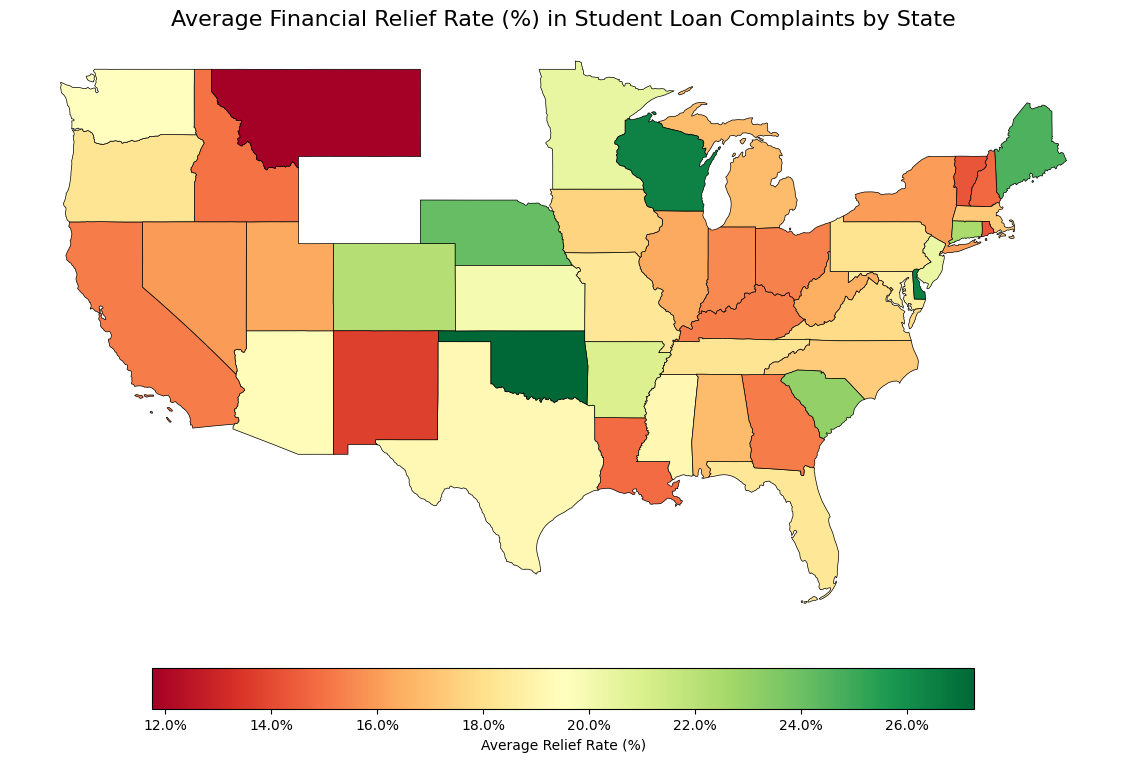

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# ============================================
# Load shapefile (adjust path to where you saved it)
# ============================================
us_states = gpd.read_file('cb_2014_us_state_20m.zip')

# Check state column name
print(us_states.columns.tolist())
print(us_states[['STUSPS','NAME']].head())

# ============================================
# Prepare state-level data from your df
# ============================================
df_map = df.dropna(subset=['Median Household Income','state']).copy()
df_map['Median Household Income'] = pd.to_numeric(df_map['Median Household Income'], errors='coerce')
df_map['any_relief'] = pd.to_numeric(df_map['any_relief'], errors='coerce')
df_map['monetary_relief'] = pd.to_numeric(df_map['monetary_relief'], errors='coerce')
df_map["Bachelor's Degree or Higher (%)"] = pd.to_numeric(df_map["Bachelor's Degree or Higher (%)"], errors='coerce')

state_stats = df_map.groupby('state').agg(
    relief_rate=('any_relief', 'mean'),
    median_income=('Median Household Income', 'mean'),
    bachelors_pct=("Bachelor's Degree or Higher (%)", 'mean'),
    n=('any_relief', 'count')
).reset_index()

# Only keep states with enough observations
state_stats = state_stats[state_stats['n'] >= 30]

# Merge with shapefile
us_map = us_states.merge(state_stats, left_on='STUSPS', right_on='state', how='inner')

# Exclude Alaska, Hawaii, territories for cleaner map
us_map = us_map[~us_map['STUSPS'].isin(['AK','HI','PR','GU','VI','AS','MP'])]

# ============================================
# MAP 1: Relief Rate by State
# ============================================
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

plot = us_map.plot(
    column='relief_rate', cmap='RdYlGn', linewidth=0.5, edgecolor='black',
    legend=False, ax=ax
)

# Add colorbar
sm = plt.cm.ScalarMappable(
    cmap='RdYlGn',
    norm=plt.Normalize(vmin=us_map['relief_rate'].min(), vmax=us_map['relief_rate'].max())
)
sm._A = []

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05)
cbar.set_label('Average Relief Rate (%)')

# Convert to percentage format
cbar.formatter = FuncFormatter(lambda x, _: f'{x*100:.1f}%')
cbar.update_ticks()

ax.set_title('Average Financial Relief Rate (%) in Student Loan Complaints by State', fontsize=16)
ax.axis('off')

plt.tight_layout()
plt.show()

#### Map 1 Interpretation：
The first map shows substantial geographic variation in financial relief rates across states, ranging from about 12% to over 27%. States in the Upper Midwest and parts of the South have relatively high relief rates, while several Western and Mountain states have the lowest rates. This variation suggests that complaint outcomes are not uniform across the country and may reflect differences in borrower characteristics, the mix of lenders in each state, or state-level institutional factors.

### 2.2.2 Map 2 (Median Household Income by State)

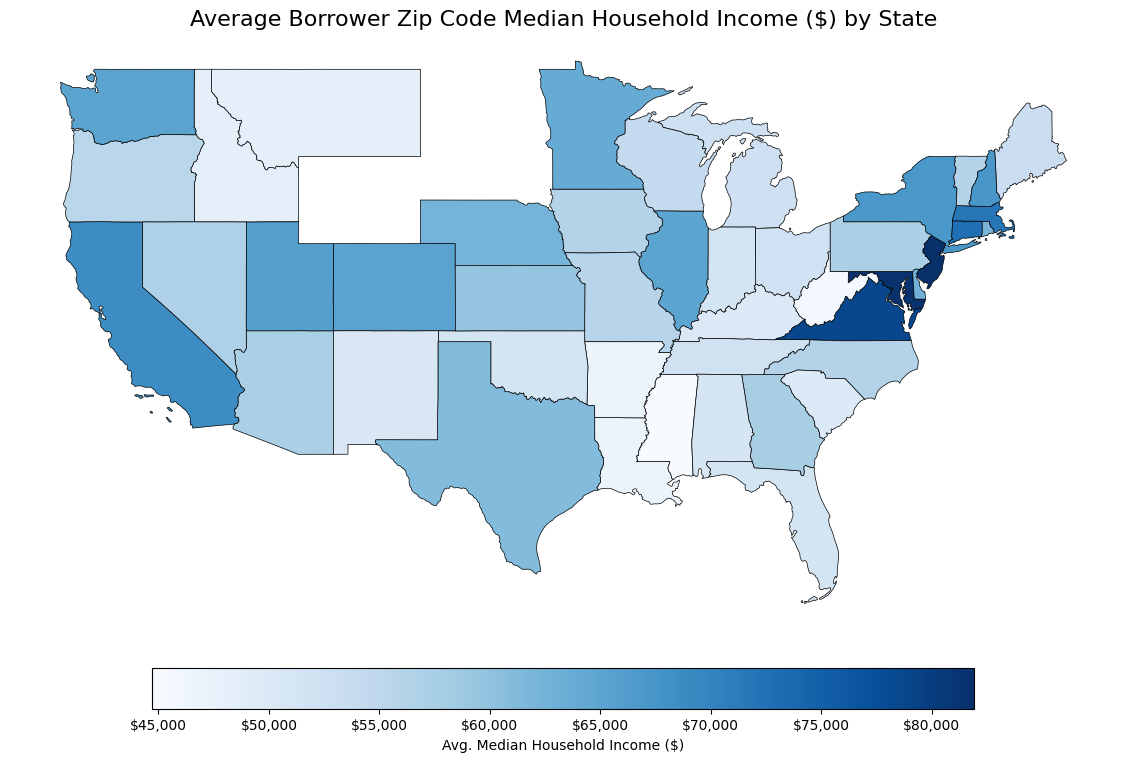

In [21]:
# ============================================
# MAP 2: Median Household Income by State
# ============================================
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
plot = us_map.plot(
    column='median_income', cmap='Blues', linewidth=0.5, edgecolor='black',
    legend=False, ax=ax
)

sm = plt.cm.ScalarMappable(
    cmap='Blues',
    norm=plt.Normalize(vmin=us_map['median_income'].min(), vmax=us_map['median_income'].max())
)
sm._A = []

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05)
cbar.set_label('Avg. Median Household Income ($)')

cbar.formatter = FuncFormatter(lambda x, _: f'${x:,.0f}')
cbar.update_ticks()

ax.set_title('Average Borrower Zip Code Median Household Income ($) by State', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

#### Map 2 Interpretation
The second map shows the average borrower zip code median household income by state. The Northeast corridor — especially Maryland, New Jersey, and Connecticut — has the highest income levels, while parts of the South and Mountain West have lower incomes. Comparing this with Map 1, some higher-income states in the Northeast tend to have moderate to high relief rates, but the relationship is not consistent. Several lower-income Southern states also show relatively high relief rates. This suggests that income alone cannot fully explain the geographic pattern in relief, and other factors such as complaint composition and firm presence likely matter.

### 2.2.3 Map 3 (Socioeconomic Inequality in Financial Relief Outcomes by State)

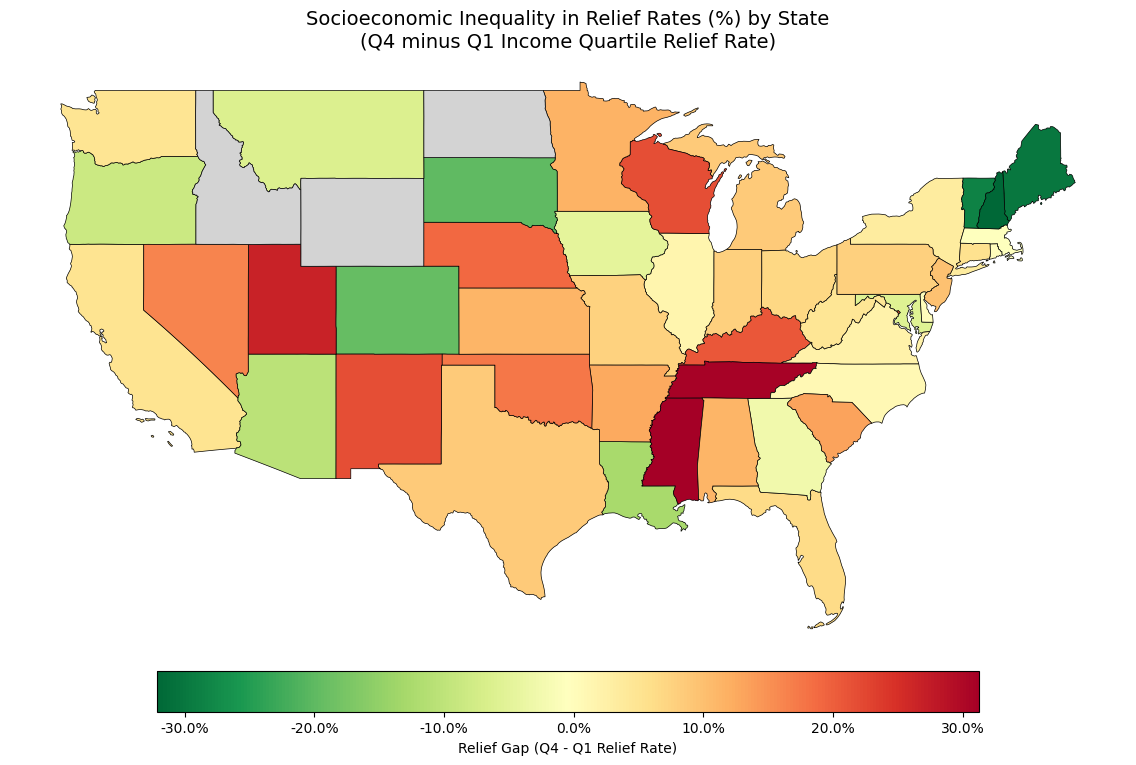

In [59]:
# ============================================
# MAP 3: Socioeconomic Inequality in Financial Relief Outcomes by State
# ============================================
df['income_quartile'] = pd.qcut(
    df['Median Household Income'],
    4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

# 2. Calculate relief rate for Q1 and Q4 in each state
state_quartile = df.dropna(subset=['state', 'income_quartile', 'any_relief']).groupby(
    ['state', 'income_quartile'], observed=True
)['any_relief'].mean().unstack()

# 3. Calculate Relief Gap = Q4 - Q1
state_quartile['relief_gap'] = state_quartile['Q4'] - state_quartile['Q1']
state_quartile = state_quartile.reset_index()

# 4. Only keep states with sufficient observations (at least in Q1 and Q4)
state_quartile = state_quartile.dropna(subset=['relief_gap'])

# 5. Merge with shapefile
us_states = gpd.read_file('cb_2014_us_state_20m.zip')
us_map = us_states.merge(state_quartile, left_on='STUSPS', right_on='state', how='left')
us_map = us_map[~us_map['STUSPS'].isin(['AK','HI','PR','GU','VI','AS','MP'])]

# 6. Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
us_map.plot(
    column='relief_gap', cmap='RdYlGn_r', linewidth=0.5,
    edgecolor='black', legend=False, ax=ax,
    missing_kwds={'color': 'lightgrey'}
)

sm = plt.cm.ScalarMappable(
    cmap='RdYlGn_r',
    norm=plt.Normalize(
        vmin=us_map['relief_gap'].min(),
        vmax=us_map['relief_gap'].max()
    )
)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.6, pad=0.02)
cbar.set_label('Relief Gap (Q4 - Q1 Relief Rate)')
cbar.formatter = FuncFormatter(lambda x, _: f'{x*100:.1f}%')
cbar.update_ticks()

ax.set_title('Socioeconomic Inequality in Relief Rates (%) by State\n(Q4 minus Q1 Income Quartile Relief Rate)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('relief_gap_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

#### Map 3 Interpretation
The third map plots the Relief Gap Index, constructed as the difference in average relief rates between the highest (Q4) and lowest (Q1) income quartile ZIP codes within each state. A positive value indicates that higher-income borrowers receive relief at a higher rate than lower-income borrowers in the same state, with darker red reflecting larger disparities. 

The map reveals substantial geographic heterogeneity: states in New England and parts of the Mountain West exhibit the largest income-based gaps in relief, while several Southern states show near-zero or even negative gaps. 

This variation suggests that the socioeconomic gradient in relief outcomes is not uniform across the country, and may reflect differences in the local composition of servicers or complaint types rather than a purely borrower-level phenomenon.

## 2.3 Regressions

### 2.3.1 Variable Construction and Econometric Specification

The relationship between relief outcomes and socioeconomic variables is assumed to be approximately linear. 

Median income enters in natural log form to reflect proportional rather than absolute effects. The remaining variables (poverty rate, unemployment rate, and bachelor's degree share) enter linearly as percentages.

The economic justification for each variable is discussed in Section 1.2.2

In [35]:
pip install imgkit

Note: you may need to restart the kernel to use updated packages.


In [53]:
# ── Regression Analysis Setup ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML
import imgkit

# ============================================
# Variable Construction
# ============================================
df_reg = df.dropna(subset=['Median Household Income']).copy()

# Ensure numeric
for col in ['Median Household Income', 'Poverty Rate (%)', 
            'Unemployment Rate (%)', "Bachelor's Degree or Higher (%)"]:
    df_reg[col] = pd.to_numeric(df_reg[col], errors='coerce')

df_reg['log_income'] = np.log(df_reg['Median Household Income'])
df_reg['NonBank'] = (df_reg['Firm_Type'] == '2_NonBank').astype(int)
df_reg['StateNP'] = (df_reg['Firm_Type'] == '3_State_NonProfit').astype(int)

for y in [2013, 2014, 2015, 2016]:
    df_reg[f'y{y}'] = (df_reg['year'] == y).astype(int)

# Issue type dummies - ensure int
issue_cols = [c for c in df_reg.columns if c.startswith('issue_')]
for c in issue_cols:
    df_reg[c] = df_reg[c].astype(int)

# Rename for cleaner regression output
df_reg = df_reg.rename(columns={
    'Poverty Rate (%)': 'poverty',
    'Unemployment Rate (%)': 'unemployment',
    "Bachelor's Degree or Higher (%)": 'bachelors',
    'issue_Repaying your loan': 'issue_repaying',
    'issue_Dealing with my lender or servicer': 'issue_dealing',
    'issue_Getting a loan': 'issue_getting',
    'issue_Problems when you are unable to pay': 'issue_unable'
})

df_reg = df_reg.dropna(subset=['log_income','poverty','unemployment','bachelors'])

### 2.3.2 Table 1: Socioeconomic Background and Financial Relief
**Equation:**
$$\text{Relief}_{i} = \alpha + \beta_1 \ln(\text{MedianIncome}_{z}) + \beta_2 \text{PovertyRate}_{z} + \beta_3 \text{UnemploymentRate}_{z} + \beta_4 \text{BachelorsPct}_{z} + \beta_5 \text{NonBank}_{i} + \beta_6 \text{StateNonProfit}_{i} + \boldsymbol{\delta} \text{Year}_{t} + \varepsilon_{i}$$

**Subscripts**:
- i = individual complaint (Each complaint is an observation)
- z = zip code (Socioeconomic variables are measured at the ZIP code level, so complaints from the same ZIP code share the same income, poverty rate, etc.)
- t = year (The time dimension used for year fixed effects)

In [37]:
# ============================================
# TABLE 1: Socioeconomic Background and Financial Relief
# ============================================

# Reg 1: Bivariate benchmark
m1 = smf.ols('any_relief ~ log_income', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 2: All socioeconomic variables
m2 = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 3: + Year fixed effects
m3 = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors + y2013 + y2014 + y2015 + y2016', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 4: + Firm type controls
m4 = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Display Table 1
table1 = Stargazer([m1, m2, m3, m4])
table1.title('Table 1: Socioeconomic Background and Financial Relief')
table1.custom_columns(['Bivariate', '+ All Socio', '+ Year FE', '+ Firm Type'], [1, 1, 1, 1])
table1.show_model_numbers(False)
table1.covariate_order(['log_income', 'poverty', 'unemployment', 'bachelors', 'NonBank', 'StateNP'])
table1.rename_covariates({'log_income': 'Log(Median Income)', 'poverty': 'Poverty Rate (%)',
                          'unemployment': 'Unemployment Rate (%)', 'bachelors': "Bachelor's Degree (%)",
                          'NonBank': 'Non-Bank Lender', 'StateNP': 'State/Non-Profit'})
table1.add_line('Year FE', ['No', 'No', 'Yes', 'Yes'])
table1.add_line('Firm Type Controls', ['No', 'No', 'No', 'Yes'])
html_content = table1.render_html()
with open('table1.html', 'w') as f:
    f.write(html_content)
display(HTML(table1.render_html()))

#### Interpretation of Table 1: 

The specifications progressively add controls to examine whether the effects of socioeconomic variables remain stable. 

Reg (1) is a bivariate benchmark: the coefficient on log(median income) is positive and significant (0.034), suggesting that borrowers from higher-income areas are more likely to receive relief. 

Reg (2) adds all socioeconomic variables, after which income becomes insignificant, likely reflecting multicollinearity among the correlated zip code-level regressors. 

Reg (3) adds year fixed effects, which does not change the results, suggesting the findings are not driven by time trends. 

Reg (4) further controls for firm type; results remain stable, and Non-Bank lenders and State/Non-Profit servicers provide significantly more relief than Banks.

Reg (4) serves as our preferred specification. It offers the most complete set of controls while remaining parsimonious, and its results are stable across the preceding columns.

### 2.3.3 Table 2: Mediation Analysis — Role of Complaint Issue Type
**Equation:**
$$\text{Relief}_{i} = \alpha + \beta_1 \ln(\text{MedianIncome}_{z}) + \beta_2 \text{PovertyRate}_{z} + \beta_3 \text{UnemploymentRate}_{z} + \beta_4 \text{BachelorsPct}_{z} + \boldsymbol{\gamma} \text{IssueType}_{i} + \beta_5 \text{NonBank}_{i} + \beta_6 \text{StateNonProfit}_{i} + \boldsymbol{\delta} \text{Year}_{t} + \varepsilon_{i}$$

**Subscripts**:
- i = individual complaint (Each complaint is an observation)
- z = zip code (Socioeconomic variables are measured at the ZIP code level, so complaints from the same ZIP code share the same income, poverty rate, etc.)
- t = year (The time dimension used for year fixed effects)

In [38]:
# ============================================
# TABLE 2: Mediation - Does Issue Type Explain the Disparity?
# ============================================

df_reg = df_reg.loc[:, ~df_reg.columns.duplicated()]

# Reg 5: Any relief + issue type
m5 = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 6: Monetary relief without issue type
m6 = smf.ols('monetary_relief ~ log_income + poverty + unemployment + bachelors + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 7: Monetary relief + issue type
m7 = smf.ols('monetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 8: Non-monetary relief without issue type
m8 = smf.ols(
    'nonmonetary_relief ~ log_income + poverty + unemployment + bachelors + ''y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
    data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 9: Non-monetary relief + issue type
m9 = smf.ols('nonmonetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
             data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Display Table 2
table2 = Stargazer([m5, m6, m7, m8, m9])
table2.title('Table 2: Mediation Analysis - Role of Complaint Issue Type')
table2.custom_columns(['Any Relief\n+ Issue', 'Monetary\nBaseline', 'Monetary\n+ Issue', 'Non-Monetary\nBaseline', 'Non-Monetary\n+ Issue'], [1, 1, 1, 1, 1])
table2.show_model_numbers(False)
table2.covariate_order(['log_income', 'poverty', 'unemployment', 'bachelors',
                        'issue_repaying', 'issue_dealing', 'issue_getting', 'issue_unable',
                        'NonBank', 'StateNP'])
table2.rename_covariates({'log_income': 'Log(Median Income)', 'poverty': 'Poverty Rate (%)',
                          'unemployment': 'Unemployment Rate (%)', 'bachelors': "Bachelor's Degree (%)",
                          'issue_repaying': 'Issue: Repaying Loan', 'issue_dealing': 'Issue: Dealing w/ Servicer',
                          'issue_getting': 'Issue: Getting a Loan', 'issue_unable': 'Issue: Unable to Pay',
                          'NonBank': 'Non-Bank Lender', 'StateNP': 'State/Non-Profit'})
table2.add_line('Year FE', ['Yes', 'Yes', 'Yes', 'Yes', 'Yes'])
table2.add_line('Firm Type Controls', ['Yes', 'Yes', 'Yes', 'Yes', 'Yes'])
table2.add_line('Issue Type Controls', ['Yes', 'No', 'Yes', 'No', 'Yes'])
html_content = table2.render_html()
with open('table2.html', 'w') as f:
    f.write(html_content)
display(HTML(table2.render_html()))

#### Interpretation of Table 2:
Table 2 tests whether complaint issue type explains the socioeconomic disparity in relief outcomes. The key test is whether socioeconomic coefficients shrink after issue type controls are added. 

Reg (5) adds issue type controls to the any-relief specification; socioeconomic coefficients change only modestly, with unemployment remaining negative and significant. 

Reg (6) and Reg (7) compare monetary relief without and with issue controls; the socioeconomic coefficients are nearly unchanged, suggesting that issue type does not meaningfully explain monetary relief disparities. Reg (8) and Reg (9) repeat this for non-monetary relief, where coefficients again remain broadly stable.

Several issue type coefficients are themselves significant, confirming that complaint type predicts relief. However, because socioeconomic coefficients change little after adding these controls, issue composition does not appear to be the main channel behind the disparity. Monetary relief is weakly associated with education, while non-monetary relief is more strongly associated with income.

### 2.3.4 Table 3: Socioeconomic Disparity by Complaint Ambiguity

Motivated by the findings in Table 2 that complaint issue type is an important predictor of relief outcomes, we further explore whether socioeconomic disparities differ across types of complaints that involve different levels of firm discretion.

To do so, we classify complaints into two groups based on sub-issue characteristics. Clear-cut complaints are those with relatively well-defined resolution criteria (e.g., “Getting an loan”, “Repaying your loan”). Ambiguous complaints are those that require greater firm discretion in determining the response, including servicing-related problems and inability-to-pay cases (e.g., “Dealing with my lender or servicer”, “Problems when you are unable to pay”, "Can't repay me loan").

We then estimate the regression separately by interacting socioeconomic variables with an indicator for ambiguous complaints, to test whether disparities are stronger in cases where firms have greater discretion.

**Equation:**
$$\text{Relief}_{i} = \alpha + \beta_1 \ln(\text{Income}_{z}) + \beta_2 \text{Poverty}_{z} + \beta_3 \text{Unemp}_{z} + \beta_4 \text{Bach}_{z} + \gamma \text{Ambiguous}_{i} + \phi_1 [\ln(\text{Income}_{z}) \times \text{Ambiguous}_{i}] + \phi_2 [\text{Poverty}_{z} \times \text{Ambiguous}_{i}] + \phi_3 [\text{Unemp}_{z} \times \text{Ambiguous}_{i}] + \phi_4 [\text{Bach}_{z} \times \text{Ambiguous}_{i}] + \text{Controls} + \varepsilon_{i}$$

**Subscripts**:
- i = individual complaint (Each complaint is an observation)
- z = zip code (Socioeconomic variables are measured at the ZIP code level, so complaints from the same ZIP code share the same income, poverty rate, etc.)
- t = year (The time dimension used for year fixed effects)

In [39]:
# ============================================
# TABLE 3: Complaint Ambiguity — Interaction Approach
# ============================================

# Create sub-issue categories
# "Clear-cut" = well-defined problems with clear resolution criteria
# "Ambiguous" = problems requiring more firm discretion

# Ambiguous complaint dummy
df_reg['ambiguous'] = df_reg['issue'].isin([
    'Dealing with my lender or servicer',  # sub: trouble with payments handled, bad info, customer service
    'Problems when you are unable to pay',  # sub: can't decrease, can't get flexible, can't postpone
    "Can’t repay my loan" # sub: can't decrease, can't get flexible, can't postpone
]).astype(int)

# Interactions: socioeconomic x ambiguous
df_reg['income_x_ambiguous'] = df_reg['log_income'] * df_reg['ambiguous']
df_reg['poverty_x_ambiguous'] = df_reg['poverty'] * df_reg['ambiguous']
df_reg['unemployment_x_ambiguous'] = df_reg['unemployment'] * df_reg['ambiguous']
df_reg['bachelors_x_ambiguous'] = df_reg['bachelors'] * df_reg['ambiguous']

# Reg 10: Any relief — income interaction only
m10 = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors + ambiguous + income_x_ambiguous + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 11: Any relief — all socioeconomic interactions
m11 = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors + ambiguous + income_x_ambiguous + poverty_x_ambiguous + unemployment_x_ambiguous + bachelors_x_ambiguous + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 12: Monetary relief — all interactions
m12 = smf.ols('monetary_relief ~ log_income + poverty + unemployment + bachelors + ambiguous + income_x_ambiguous + poverty_x_ambiguous + unemployment_x_ambiguous + bachelors_x_ambiguous + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 13: Nonmonetary relief — all interactions
m13 = smf.ols('nonmonetary_relief ~ log_income + poverty + unemployment + bachelors + ambiguous + income_x_ambiguous + poverty_x_ambiguous + unemployment_x_ambiguous + bachelors_x_ambiguous + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

table3 = Stargazer([m10, m11, m12, m13])
table3.title('Table 3: Socioeconomic Disparity and Complaint Ambiguity')
table3.custom_columns(['Any Relief\nIncome Int.', 'Any Relief\nAll Int.', 'Monetary\nAll Int.', 'Non-Monetary\nAll Int.'], [1, 1, 1, 1])
table3.show_model_numbers(False)
table3.covariate_order(['log_income', 'poverty', 'unemployment', 'bachelors',
                        'ambiguous',
                        'income_x_ambiguous', 'poverty_x_ambiguous', 
                        'unemployment_x_ambiguous', 'bachelors_x_ambiguous',
                        'NonBank', 'StateNP'])
table3.rename_covariates({
    'log_income': 'Log(Median Income)', 'poverty': 'Poverty Rate (%)',
    'unemployment': 'Unemployment Rate (%)', 'bachelors': "Bachelor's Degree (%)",
    'ambiguous': 'Ambiguous Complaint',
    'income_x_ambiguous': 'Log(Income) × Ambiguous',
    'poverty_x_ambiguous': 'Poverty × Ambiguous',
    'unemployment_x_ambiguous': 'Unemployment × Ambiguous',
    'bachelors_x_ambiguous': "Bachelor's × Ambiguous",
    'NonBank': 'Non-Bank Lender', 'StateNP': 'State/Non-Profit'})
table3.add_line('Year FE', ['Yes', 'Yes', 'Yes', 'Yes'])
table3.add_line('Firm Type Controls', ['Yes', 'Yes', 'Yes', 'Yes'])
html_content = table3.render_html()
with open('table3.html', 'w') as f:
    f.write(html_content)
display(HTML(table3.render_html()))

#### Interpretation of Table 3:

We classify complaints into "clear-cut" types with well-defined resolution criteria (Getting a loan, Repaying your loan) and "ambiguous" types requiring greater firm discretion (Dealing with my lender or servicer, Problems when you are unable to pay, Can't repay my loan). We then interact socioeconomic variables with an ambiguity indicator.

Reg (10) includes only the income-ambiguity interaction, which is positive and significant (0.043), indicating that income matters more for relief in ambiguous complaints. 

Reg (11) adds all socioeconomic interactions; the income interaction remains positive but less precisely estimated, while other interactions are small and mostly insignificant. 

Reg (12) examines monetary relief, where no interaction terms are significant. 

Reg (13) examines non-monetary relief, where the income interaction remains positive but insignificant.

Overall, there is suggestive evidence that disparities are more pronounced in ambiguous complaints, particularly along the income dimension, but the results are not consistently significant and should be interpreted with caution.

### 2.3.5 Table 4: Decomposing Response

To better understand how the observed socioeconomic disparity manifests in complaint outcomes, we decompose the overall relief indicator into four mutually exclusive response categories: monetary relief, non-monetary relief, explanation only, and no relief. While previous results focus on whether a complaint receives any relief, this analysis examines the type of resolution provided.

**Equation:**
$$\text{Response}_{i} = \alpha + \beta_1 \ln(\text{MedianIncome}_{z}) + \beta_2 \text{PovertyRate}_{z} + \beta_3 \text{UnemploymentRate}_{z} + \beta_4 \text{BachelorsPct}_{z} + \boldsymbol{\gamma} \text{IssueType}_{i} + \beta_5 \text{NonBank}_{i} + \beta_6 \text{StateNonProfit}_{i} + \boldsymbol{\delta} \text{Year}_{t} + \varepsilon_{i}$$

**Subscripts**:
- i = individual complaint (Each complaint is an observation)
- z = zip code (Socioeconomic variables are measured at the ZIP code level, so complaints from the same ZIP code share the same income, poverty rate, etc.)
- t = year (The time dimension used for year fixed effects)

In [401]:
# ============================================
# TABLE 4: Decomposing Relief - Four Response Types as Y
# ============================================

# Reg 14: Y = monetary relief
m14 = smf.ols('monetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 15: Y = non-monetary relief
m15 = smf.ols('nonmonetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 16: Y = explanation only
m16 = smf.ols('explanation_only ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

# Reg 17: Y = without relief
m17 = smf.ols('no_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP', 
              data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

table4 = Stargazer([m14, m15, m16, m17])
table4.title('Table 4: Decomposing Complaint Resolution Outcomes')
table4.custom_columns(['Monetary Relief', 'Non-Monetary Relief', 'Explanation Only', 'Without Relief'], [1, 1, 1, 1])
table4.show_model_numbers(False)
table4.covariate_order(['log_income', 'poverty', 'unemployment', 'bachelors',
                        'issue_repaying', 'issue_dealing', 'issue_getting', 'issue_unable',
                        'NonBank', 'StateNP'])
table4.rename_covariates({'log_income': 'Log(Median Income)', 'poverty': 'Poverty Rate (%)',
                          'unemployment': 'Unemployment Rate (%)', 'bachelors': "Bachelor's Degree (%)",
                          'issue_repaying': 'Issue: Repaying Loan', 'issue_dealing': 'Issue: Dealing w/ Servicer',
                          'issue_getting': 'Issue: Getting a Loan', 'issue_unable': 'Issue: Unable to Pay',
                          'NonBank': 'Non-Bank Lender', 'StateNP': 'State/Non-Profit'})
table4.add_line('Year FE', ['Yes', 'Yes', 'Yes', 'Yes'])
table4.add_line('Firm Type Controls', ['Yes', 'Yes', 'Yes', 'Yes'])
table4.add_line('Issue Type Controls', ['Yes', 'Yes', 'Yes', 'Yes'])
display(HTML(table4.render_html()))

#### Interpretation of Table 4:

We decompose outcomes into four mutually exclusive categories: monetary relief, non-monetary relief, explanation only, and no relief. 

Reg (14) shows that monetary relief is positively associated with bachelor's degree share (p<0.01) and negatively associated with poverty (p<0.05), while income is not significant, suggesting monetary disparities relate more to education than income. 

Reg (15) shows that non-monetary relief is positively associated with income (0.030, p<0.05) and negatively associated with unemployment (p<0.01). 

Reg (16) finds weaker and less consistent socioeconomic effects for explanation-only responses. 

Reg (17) shows that no-relief outcomes are significantly more likely for borrowers from lower-income (p<0.01) and higher-unemployment areas (p<0.01).

These results show that socioeconomic disparities operate differently across response types: more advantaged areas receive more meaningful resolution, while disadvantaged areas are more likely to receive no relief.

### 2.3.6 Table 5: Robustness Checks
**Equation:**
$$
\text{Relief}_i = \alpha + \beta_1 \ln(\text{MedianIncome}_z) + \beta_2 \text{PovertyRate}_z + \beta_3 \text{UnemploymentRate}_z + \beta_4 \text{BachelorsPct}_z + \beta_5 \text{NonBank}_i + \beta_6 \text{StateNonProfit}_i + \boldsymbol{\delta} \text{Year}_t + \varepsilon_i
$$

**Subscripts**:
- i = individual complaint (Each complaint is an observation)
- z = zip code (Socioeconomic variables are measured at the ZIP code level, so complaints from the same ZIP code share the same income, poverty rate, etc.)
- t = year (The time dimension used for year fixed effects)

The robustness check re-estimates this equation on a restricted sample that excludes all complaints filed against Navient. Standard errors are clustered at the firm level in all specifications.

In [402]:
# ==============================================
# TABLE 5: Robustness Checks (Navient Exclusion)
# ==============================================
# Exclude Navient from sample
df_no_nav = df_reg[~df_reg['company'].str.contains('Navient', case=False, na=False)].copy()
print(f"Original N: {len(df_reg)} | After excluding Navient: {len(df_no_nav)}")

# Any relief: full vs no Navient
r_any_full = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
                     data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

r_any_excl = smf.ols('any_relief ~ log_income + poverty + unemployment + bachelors + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
                     data=df_no_nav).fit(cov_type='cluster', cov_kwds={'groups': df_no_nav['company']})

# Monetary relief: full vs no Navient
r_mon_full = smf.ols('monetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
                     data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

r_mon_excl = smf.ols('monetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
                     data=df_no_nav).fit(cov_type='cluster', cov_kwds={'groups': df_no_nav['company']})

# Non-monetary relief: full vs no Navient
r_non_full = smf.ols('nonmonetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
                     data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['company']})

r_non_excl = smf.ols('nonmonetary_relief ~ log_income + poverty + unemployment + bachelors + issue_repaying + issue_dealing + issue_getting + issue_unable + y2013 + y2014 + y2015 + y2016 + NonBank + StateNP',
                     data=df_no_nav).fit(cov_type='cluster', cov_kwds={'groups': df_no_nav['company']})

# Build Stargazer table
table5 = Stargazer([r_any_full, r_any_excl, r_mon_full, r_mon_excl, r_non_full, r_non_excl])
table5.title('Table 5: Robustness Check — Navient Exclusion')
table5.custom_columns(
    ['Any Relief', 'Any Relief', 'Monetary Relief', 'Monetary Relief', 'Non-Monetary Relief', 'Non-Monetary Relief'],
    [1, 1, 1, 1, 1, 1]
)
table5.show_model_numbers(False)
table5.add_line("Sample", ["Full", "No Navient", "Full", "No Navient", "Full", "No Navient"])
table5.covariate_order([
    'log_income', 'poverty', 'unemployment', 'bachelors',
    'issue_repaying', 'issue_dealing', 'issue_getting', 'issue_unable',
    'NonBank', 'StateNP',
])
table5.rename_covariates({
    'log_income':    'Log(Median Income)',
    'poverty':       'Poverty Rate (%)',
    'unemployment':  'Unemployment Rate (%)',
    'bachelors':     "Bachelor's Degree (%)",
    'issue_repaying':'Issue: Repaying Loan',
    'issue_dealing': 'Issue: Dealing w/ Servicer',
    'issue_getting': 'Issue: Getting a Loan',
    'issue_unable':  'Issue: Unable to Pay',
    'NonBank':       'Non-Bank Lender',
    'StateNP':       'State/Non-Profit',
})
table5.add_line('Year FE',           ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'])
table5.add_line('Firm Type Controls',['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'])
table5.add_line('Issue Type Controls',['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes'])
display(HTML(table5.render_html()))

Original N: 12028 | After excluding Navient: 6544


#### Interpretation of Table 5:

Table 5 re-estimates the main specifications after excluding Navient, which accounts for approximately 46% of the sample. 

Columns (1) and (2) show that the NonBank coefficient on any relief falls from 0.072 to 0.037 and loses significance after Navient is excluded, indicating that the NonBank effect is largely driven by Navient. The State/Non-Profit coefficient remains stable (0.076 vs. 0.078) and significant. 

Columns (3) and (4) show the same pattern for monetary relief: the NonBank effect disappears without Navient. 

Columns (5) and (6) show that for non-monetary relief, both firm type coefficients are stable across samples, with State/Non-Profit remaining large and significant (0.084 vs. 0.088).

The NonBank effect should therefore be interpreted cautiously, while the State/Non-Profit effect is robust across all outcomes and samples.

# Final Project

## 3.1 Potential Data to Scrape

**Main Message**

Our project investigates whether local socioeconomic characteristics affect a borrower's likelihood of receiving relief from financial institutions. Initially, we hypothesized that the "issue type" might be the main mechanism. We assumed that areas with lower income and education levels had a higher proportion of "hard-to-resolve" issues (like struggling to repay a loan), which generally lead to lower relief rates.

However, our regression results in Section 2.3 showed that even after controlling for the issue type, high-income areas still receive more non-monetary relief, and high-education areas still receive more monetary relief. This clearly indicates that issue type is not the primary mechanism.

We now consider that the underlying mechanism may operate through the linguistic complexity of financial institutions' legal documents. Complex, ambiguous contractual language expands firm discretion in resolving complaints. When obligations are vaguely defined, servicers have greater latitude to determine outcomes with less accountability. Critically, our regression results (Table 3) already document that the income gradient in relief is significantly larger in ambiguous complaints (Log(Income) × Ambiguous = 0.043, p<0.01), consistent with firms exercising this discretion in ways that systematically disadvantage lower-SES borrowers. To empirically measure this discretion channel, we scrape the historical Terms of Service (TOS) texts of these financial institutions and calculate their readability scores as a proxy for contractual ambiguity.

- **The reason why this data enhances the paper:**
It provides a quantitative measure of "legal barriers." By calculating the readability scores (e.g., Flesch-Kincaid Grade) of the scraped TOS documents, we can add a new variable to our model. This allows us to test if highly complex text is the actual mechanism that disproportionately prevents lower-SES communities from successfully getting relief.

- **The address of the website:**
We will scrape the historical web pages using the Internet Archive's Wayback Machine (specifically utilizing their CDX API at web.archive.org/cdx/search/cdx to find historical snapshots).

- **What data is being scraped:**
We are scraping the raw HTML text of the core "Terms of Service," "User Agreement," or "Legal" pages for the 50+ companies in our dataset between 2010 and 2018. We will strip away all HTML tags to extract just the pure legal text body.

- **How it merges and how we will use it:**
After scraping, we will use Natural Language Processing (NLP) tools to calculate a reading difficulty score (Word Count and Flesch-Kincaid Grade) for each text. Note that Flesch-Kincaid Grade Level scores above 18 should not be interpreted literally as requiring 18 years of formal education, but rather as an indicator of highly technical and complex sentence structures that exceed the reading level of an average adult consumer. We will aggregate these scores by Company and Year. In future work, merging these TOS readability scores with complaint-level data would allow us to test whether firms with more complex contracts exhibit larger socioeconomic gaps in relief rates, for instance through an interaction term between local education level and firm-level Flesch-Kincaid grade.

## 3.2 Potential Challenges

Since our research dataset spans 2012 to 2016, we scraped TOS data from 2010 to 2018 to provide sufficient coverage. To capture variations efficiently without overloading the API, we sampled historical snapshots bi-annually (June and December).

During execution, we faced several technical challenges. The primary issue was handling HTTP redirects (301/302), as financial institutions frequently restructured their websites over the 8-year period. We resolved this by configuring our requests to accept redirect status codes. Additionally, making back-to-back requests for 50+ firms triggered server connection limits. We mitigated this by implementing automated backoff and retry mechanisms. Finally, because webpage structures changed over time, we used BeautifulSoup to strip away noisy HTML elements such as navigation bars and footers, ensuring that our NLP analysis only evaluated the core legal text.

A secondary challenge concerns firms with zero archived snapshots. Sallie Mae and Campus Student Funding returned no results from the CDX API, likely due to URL path changes after corporate restructuring or because the firm's web presence was never captured by the Internet Archive. These firms are excluded from the TOS corpus, which may introduce a minor selection bias.

## 3.3 Scraping Data from a Website

First, extracting historical Terms of Service documents (2010-2018) for financial institutions using the Internet Archive's Wayback Machine.

Key operations:
1. Robust Connection: Implements automatic HTTP retries to handle server instability.

2. Snapshot Retrieval: Queries the CDX API to retrieve bi-annual historical web snapshots (targeting June and December) for a given list of URLs.

3. Text Cleaning: Parses archived HTML using BeautifulSoup, stripping out irrelevant web elements (scripts, styles, navbars) to extract pure legal text.

4. Incremental Saving: Iteratively processes seed URLs and appends the cleaned corpus to a CSV file for downstream Natural Language Processing (NLP) analysis.

In [ ]:
import os
import pandas as pd
import requests
import time
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Added retry logic to handle transient network issues and prevent script from crashing due to temporary failures
session = requests.Session()
retries = Retry(total=5, backoff_factor=1, status_forcelist=[ 500, 502, 503, 504 ])
session.mount('https://', HTTPAdapter(max_retries=retries))

def get_cdx_snapshots(url, start_year="2010", end_year="2018"):
    # Upgrade to https for CDX API endpoint
    cdx_api_url = "https://web.archive.org/cdx/search/cdx"
    params = {
        "url": url,
        "output": "json",
        "from": start_year,
        "to": end_year,
        "fl": "timestamp,original", 
        "collapse": "timestamp:6", 
        "filter": "statuscode:[23].." # Allows 2xx and 3xx status codes, which are more likely to contain valid TOS content
    }
    
    try:
        response = session.get(cdx_api_url, params=params, timeout=30)
        if response.status_code == 200:
            data = response.json()
            if len(data) > 1:
                return data[1:]
        return []
    except Exception as e:
        print(f"[CDX API ERROR] Failed to fetch index for {url}: {e}")
        return []

def extract_text_from_html(timestamp, original_url):
    # Use https for archive URL to ensure secure connection and compatibility with modern web standards
    archive_url = f"https://web.archive.org/web/{timestamp}/{original_url}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Economics Research Project; Toronto) AppleWebKit/537.36"
    }
    
    try:
        response = session.get(archive_url, headers=headers, timeout=30)
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            for script in soup(["script", "style", "nav", "footer"]):
                script.extract()
            text = soup.get_text(separator=' ', strip=True)
            return text, archive_url
        return None, archive_url
    except Exception as e:
        print(f"[SCRAPING ERROR] Failed to fetch HTML from {archive_url}: {e}")
        return None, archive_url

# ==========================================
# Main Execution Block
# ==========================================

df = pd.read_csv("Firms_Seed_URLs_Cleaned.csv")
df = df.dropna(subset=['Seed_URL']) 

output_file = "Historical_TOS_Corpus_2010_2018.csv"
write_header = not os.path.exists(output_file)

print("Starting historical TOS extraction...\n")

for index, row in df.iterrows():
    company = row['Company']
    seed_url = row['Seed_URL']
    
    if "Manual" in str(seed_url) or "Not found" in str(seed_url):
        continue
        
    print(f"Processing {company}: {seed_url}")
    
    firm_dataset = [] 
    
    snapshots = get_cdx_snapshots(seed_url, start_year="2010", end_year="2018")
    target_months = ['06', '12']
    sampled_snapshots = [s for s in snapshots if s[0][4:6] in target_months]
    
    if not sampled_snapshots and snapshots:
        sampled_snapshots = snapshots[::max(1, len(snapshots)//16)]
        
    print(f"  -> Found {len(sampled_snapshots)} target snapshots.")
    
    for snap in sampled_snapshots:
        timestamp = snap[0]
        orig_url = snap[1]
        
        raw_text, archive_url = extract_text_from_html(timestamp, orig_url)
        
        if raw_text:
            firm_dataset.append({
                "Company": company,
                "Year": timestamp[:4],
                "Month": timestamp[4:6],
                "TOS_Text": raw_text,
                "Archive_URL": archive_url
            })
        time.sleep(3) 
        
    print(f"  -> Completed extraction for {company}.\n")
    
    if firm_dataset:
        temp_df = pd.DataFrame(firm_dataset)
        temp_df.to_csv(output_file, mode='a', header=write_header, index=False, encoding='utf-8')
        write_header = False 

print(f"🎉 All extractions complete! Corpus saved to {output_file}")

Starting historical TOS extraction...

Processing Wells Fargo & Company: wellsfargo.com/legal
  -> Found 1 target snapshots.
  -> Completed extraction for Wells Fargo & Company.

Processing JPMorgan Chase & Co.: chase.com
  -> Found 18 target snapshots.
  -> Completed extraction for JPMorgan Chase & Co..

Processing Citibank: citi.com
  -> Found 17 target snapshots.
  -> Completed extraction for Citibank.

Processing Bank of America: bankofamerica.com
  -> Found 18 target snapshots.
  -> Completed extraction for Bank of America.

Processing U.S. Bancorp: usbank.com
  -> Found 18 target snapshots.
  -> Completed extraction for U.S. Bancorp.

Processing PNC Bank N.A.: pnc.com
  -> Found 17 target snapshots.
  -> Completed extraction for PNC Bank N.A..

Processing KeyBank NA: key.com
  -> Found 18 target snapshots.
  -> Completed extraction for KeyBank NA.

Processing Citizens Financial Group, Inc.: citizensbank.com
  -> Found 18 target snapshots.
  -> Completed extraction for Citizens Fi

Installing the module needed for NLP analysis

In [ ]:
pip install textstat pandas

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=18173) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 59.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [textstat]3/5 [nltk]
Note: you may need to restart the kernel to use updated packages.


Using the scraped data to do NLP analysis:

In [ ]:
import pandas as pd
import textstat
import time
import ssl
import nltk

# ==========================================
# Allow unverified SSL context for NLTK downloads (if needed)
# ==========================================
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download required NLTK resources (quiet=True to suppress output)
print("Downloading required NLTK dictionaries...")
nltk.download('cmudict', quiet=True)
nltk.download('punkt', quiet=True)
print("Download complete!\n")

# ==========================================
# NLP Readability Analysis
# ==========================================
print("Starting NLP Readability Analysis...")

# 1. Load the scraped historical TOS corpus
df = pd.read_csv("Historical_TOS_Corpus_2010_2018.csv")

df['TOS_Text'] = df['TOS_Text'].astype(str)
df = df[df['TOS_Text'].str.strip() != '']

def calculate_nlp_metrics(text):
    try:
        # Flesch-Kincaid Grade Level (Higher = harder to read)
        grade_level = textstat.flesch_kincaid_grade(text)
        
        # Flesch Reading Ease (0-100, Lower = harder to read)
        reading_ease = textstat.flesch_reading_ease(text)
        
        # Word count
        word_count = textstat.lexicon_count(text)
        
        # Average sentence length
        sentence_count = textstat.sentence_count(text)
        avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
        
        return pd.Series({
            'Flesch_Kincaid_Grade': grade_level,
            'Reading_Ease': reading_ease,
            'Word_Count': word_count,
            'Avg_Sentence_Length': round(avg_sentence_length, 2)
        })
    except Exception as e:
        return pd.Series({
            'Flesch_Kincaid_Grade': None,
            'Reading_Ease': None,
            'Word_Count': None,
            'Avg_Sentence_Length': None
        })

print(f"Processing {len(df)} documents. This might take a minute...")

# 2. Apply the NLP function to the text column
start_time = time.time()
nlp_results = df['TOS_Text'].apply(calculate_nlp_metrics)

# 3. Concatenate the new metrics with the original dataframe
final_df = pd.concat([df, nlp_results], axis=1)

# Drop any rows where calculation failed
final_df = final_df.dropna(subset=['Flesch_Kincaid_Grade'])

# 4. Save the NLP enhanced dataset
output_filename = "TOS_NLP_Scores_2010_2018.csv"
final_df.to_csv(output_filename, index=False, encoding='utf-8')

end_time = time.time()
print(f"\n🎉 NLP Analysis Complete! Processed in {round(end_time - start_time, 2)} seconds.")
print(f"Dataset saved to {output_filename}")

print("\nPreview of the NLP scores:")
print(final_df[['Company', 'Year', 'Flesch_Kincaid_Grade', 'Reading_Ease', 'Word_Count']].head(5).to_string())

Download complete!

Starting NLP Readability Analysis...
Processing 686 documents. This might take a minute...

🎉 NLP Analysis Complete! Processed in 1.45 seconds.
Dataset saved to TOS_NLP_Scores_2010_2018.csv

Preview of the NLP scores:
                Company  Year  Flesch_Kincaid_Grade  Reading_Ease  Word_Count
0  JPMorgan Chase & Co.  2010             17.394118     20.820196       170.0
1  JPMorgan Chase & Co.  2010             16.478857     21.445143       175.0
2  JPMorgan Chase & Co.  2011             31.756577   -121.512997      1627.0
3  JPMorgan Chase & Co.  2011             32.106195   -122.774597      2988.0
4  JPMorgan Chase & Co.  2012             41.942868   -193.870574      8476.0


## 3.4 Visualizing the Scraped Dataset

### 3.4.1 Overall Distribution of Contract Complexity

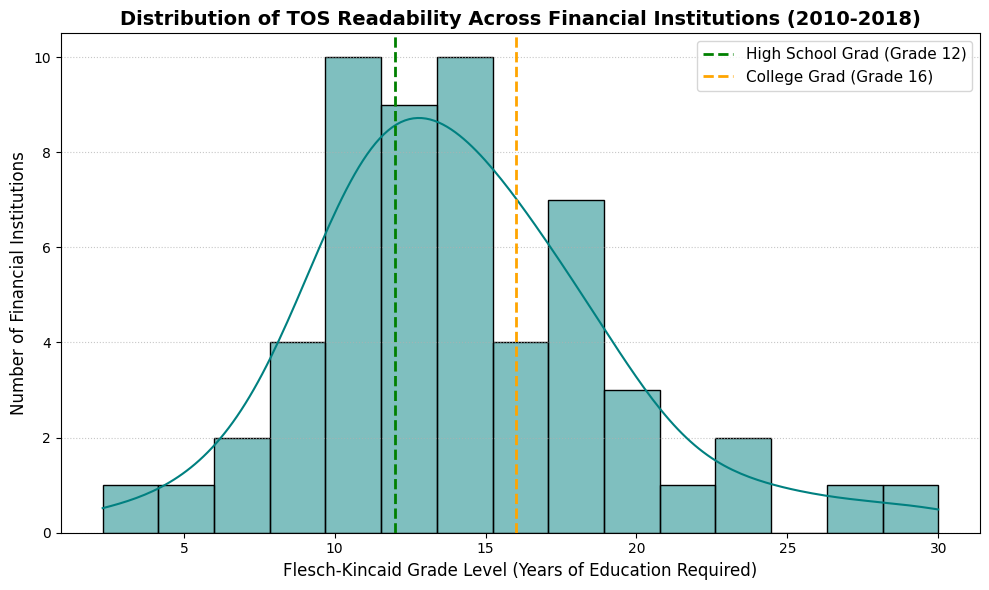

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reload the NLP scores dataset
nlp_df = pd.read_csv("TOS_NLP_Scores_2010_2018.csv")

# Get average Flesch-Kincaid Grade level for each company across all years
firm_nlp = nlp_df.groupby('Company')['Flesch_Kincaid_Grade'].mean().reset_index()

# 2. Create a visually stunning histogram of the Flesch-Kincaid Grade levels across firms
plt.figure(figsize=(10, 6))
sns.histplot(data=firm_nlp, x='Flesch_Kincaid_Grade', bins=15, kde=True, color='teal', edgecolor='black')

# 3. Add vertical lines for key education levels
plt.axvline(x=12, color='green', linestyle='--', linewidth=2, label='High School Grad (Grade 12)')
plt.axvline(x=16, color='orange', linestyle='--', linewidth=2, label='College Grad (Grade 16)')

# Add titles, labels, legend, and grid for better readability
plt.title('Distribution of TOS Readability Across Financial Institutions (2010-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Flesch-Kincaid Grade Level (Years of Education Required)', fontsize=12)
plt.ylabel('Number of Financial Institutions', fontsize=12)

plt.legend(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# Save the plot with high resolution
plt.savefig('TOS_Distribution_Visualization.png', dpi=300)
plt.show()

#### Visualization Interpretation:

The histogram illustrates the distribution of the Flesch-Kincaid Grade Level for the scraped Terms of Service (TOS) documents across the financial institutions in our sample. From the graph we can observe that most TOS documents are concentrated between Grade 10 and Grade 18, already exceeding the reading level of the average consumer. In addition, there is a noticeable right tail extending beyond Grade 20, indicating the presence of extremely complex legal language.

Crucially, Flesch-Kincaid scores above 18 should not be interpreted literally as years of education, but rather as a signal of highly technical and difficult sentence structures. This suggests that many documents are written in a way that is difficult for non-experts to understand.

The fact that a large share of documents exceed the college-level threshold supports the idea that financial institutions rely on complex language, which may act as a cognitive barrier. As a result, consumers, especially those from lower-education backgrounds may struggle to fully understand the terms governing their complaints.

### 3.4.2 Average TOS Complexity Over Time (2010–2018)

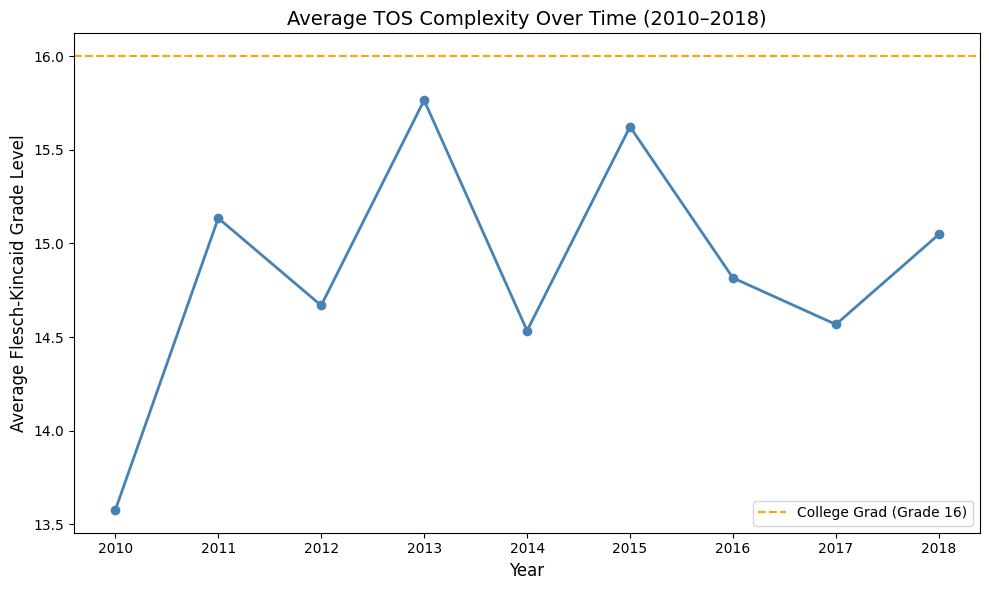

In [55]:
yearly_complexity = nlp_df.groupby('Year')['Flesch_Kincaid_Grade'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_complexity['Year'], yearly_complexity['Flesch_Kincaid_Grade'], 
         marker='o', linewidth=2, color='steelblue')
plt.axhline(y=16, color='orange', linestyle='--', label='College Grad (Grade 16)')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Flesch-Kincaid Grade Level', fontsize=12)
plt.title('Average TOS Complexity Over Time (2010–2018)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation:
The trend line reveals no systematic increase in TOS complexity over the 2010–2018 period. Average Flesch-Kincaid grades fluctuate between 13.5 and 15.8, remaining consistently below the college-graduate threshold (Grade 16) throughout. 

This suggests that contractual complexity is a persistent structural feature of the student loan servicing industry rather than a product of regulatory changes over time. Consequently, firm-level TOS complexity may serve as a more stable proxy for institutional discretion than a time-varying one, making it a potentially useful control variable in future regression analyses examining socioeconomic disparities in relief outcomes.

## 3.5 Regression Tree

### 1. The Objective Function of a Regression Tree
Unlike OLS, which minimizes the sum of squared residuals assuming constant marginal effects across the entire sample, a regression tree is a non-parametric model that recursively partitions the feature space into distinct, non-overlapping regions $R_1, R_2, ..., R_J$. The objective function minimizes the Residual Sum of Squares across all regions:

$$RSS = \sum_{j=1}^{J} \sum_{i \in R_j} (any\_relief_i - \hat{any\_relief}_{R_j})^2$$


The tree algorithm searches through all explanatory variables to find the optimal splitting points. For each region $R_j$, the model calculates the average relief rate ($\hat{any\_relief}_{R_j}$) of all complaints in that region. The goal is to draw boundaries so that the actual relief outcome of each complaint is as close as possible to the predicted average of its assigned region, minimizing the total prediction error.


### Regularization Parameters and Their Effects

Without constraints, a regression tree can keep splitting until every observation has its own leaf, achieving an RSS of zero but severely overfitting the data. We set two regularization parameters to prevent this:

1. Max depth is set to 3, limiting the tree to three vertical levels. This forces the model to capture only the most dominant structural splits rather than fitting to noise.

2. Min samples leaf is set to 300, requiring every final region to contain at least 300 complaints. This prevents the tree from creating overfitted rules based on small groups of observations.

These constraints control the bias-variance tradeoff, keeping the model generalizable and interpretable.

Preparing data for the Regression Tree (Preferred Specification)...
Data ready! Training the Regression Tree with 12028 observations and 10 features...
Model fitting complete! Generating visualization...



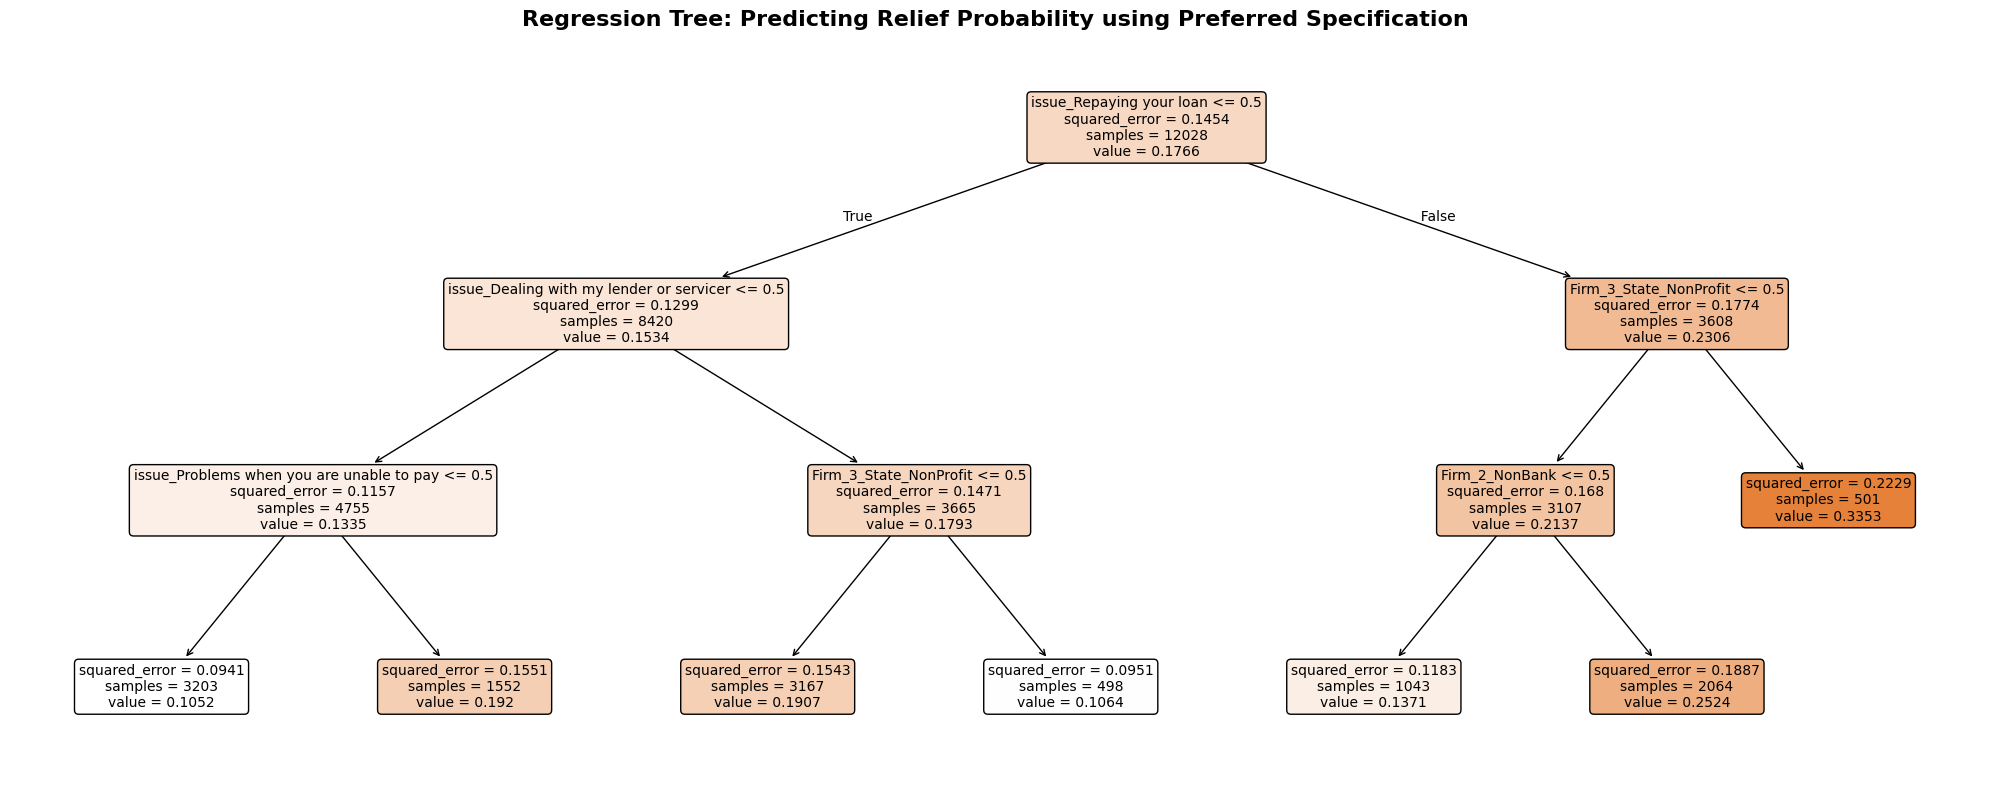

Feature Importances in this Preferred Tree:
- Firm_2_NonBank: 0.2008
- Firm_3_State_NonProfit: 0.2057
- issue_Dealing with my lender or servicer: 0.0943
- issue_Problems when you are unable to pay: 0.1716
- issue_Repaying your loan: 0.3276


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

print("Preparing data for the Regression Tree (Preferred Specification)...")

# 1. Reload the main dataset with all the cleaned variables (make sure it has the columns we need for the preferred spec) 
df = pd.read_csv("df.csv", low_memory=False)

# 2. Clean and convert percentage columns to numeric (remove % signs and convert to float)
def clean_pct(x):
    x_str = str(x).replace('%', '').replace(',', '').strip()
    try:
        return float(x_str)
    except ValueError:
        return np.nan

df['Unemployment_Rate'] = df['Unemployment Rate (%)'].apply(clean_pct)
df['Poverty_Rate'] = df['Poverty Rate (%)'].apply(clean_pct)
df['Bachelor_Rate'] = df["Bachelor's Degree or Higher (%)"].apply(clean_pct)

# 3. Create dummies for Firm_Type (Bank is the reference category)
firm_dummies = pd.get_dummies(df['Firm_Type'], prefix='Firm', drop_first=True)
df = pd.concat([df, firm_dummies], axis=1)
firm_cols = firm_dummies.columns.tolist()

# 4. Create list of issue type dummies
issue_cols = [
    'issue_Dealing with my lender or servicer',
    'issue_Getting a loan',
    'issue_Problems when you are unable to pay',
    'issue_Repaying your loan'
]

# 5. Combine all features for the preferred specification
features = ['Poverty_Rate', 'Bachelor_Rate', 'log_income', 'Unemployment_Rate'] + firm_cols + issue_cols
target = 'any_relief'

# Drop rows with missing values in any of the features or target to ensure the tree is trained on complete cases
tree_df = df.dropna(subset=features + [target]).copy()

X = tree_df[features]
y = tree_df[target]

print(f"Data ready! Training the Regression Tree with {len(X)} observations and {len(features)} features...")

# ==========================================
# 6. Construct the Regression Tree with the preferred specification
# ==========================================
reg_tree = DecisionTreeRegressor(
    max_depth=3,              # Constrain depth for better interpretability
    min_samples_leaf=300,     # Require a minimum number of samples in each leaf to avoid overfitting
    random_state=42
)

reg_tree.fit(X, y)
print("Model fitting complete! Generating visualization...\n")

# ==========================================
# 7. Visualize the tree with enhanced aesthetics 
# ==========================================
plt.figure(figsize=(20, 8))  
plot_tree(
    reg_tree, 
    feature_names=features, 
    filled=True, 
    rounded=True, 
    fontsize=10,
    precision=4,
    proportion=False
)
plt.title("Regression Tree: Predicting Relief Probability using Preferred Specification", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Regression_Tree_Preferred_Spec.png", dpi=300)
plt.show()

# 8. Print feature importances for the preferred tree
print("Feature Importances in this Preferred Tree:")
for feature, imp in zip(features, reg_tree.feature_importances_):
    if imp > 0: # Only print features that were actually used in the splits
        print(f"- {feature}: {imp:.4f}")

### Interpretation of Regression Tree Results

Notably, all four socioeconomic variables, log income, poverty rate, unemployment rate, and bachelor's degree share have zero feature importance in the preferred specification tree. This is not a failure of the model, but rather an informative null result: when the tree is constrained to depth 3 and must allocate its splitting power among all included variables, institutional factors (firm type, issue type) dominate so completely that socioeconomic characteristics are never selected as splitting criteria. 

This contrasts with the OLS results in Regression Table 1, where unemployment is consistently negative and significant. The discrepancy reflects a fundamental difference between the two methods that OLS estimates marginal effects holding all else constant, while the regression tree selects variables based on their unconditional ability to reduce prediction error. The implication is that socioeconomic disparities, while statistically detectable on average, may be too small in magnitude to drive meaningful splits in the data relative to the institutional factors that dominate complaint outcomes.

Starting Part 5: Kitchen Sink Regression Tree...
Training Kitchen Sink Tree with 19 features and 12028 observations...


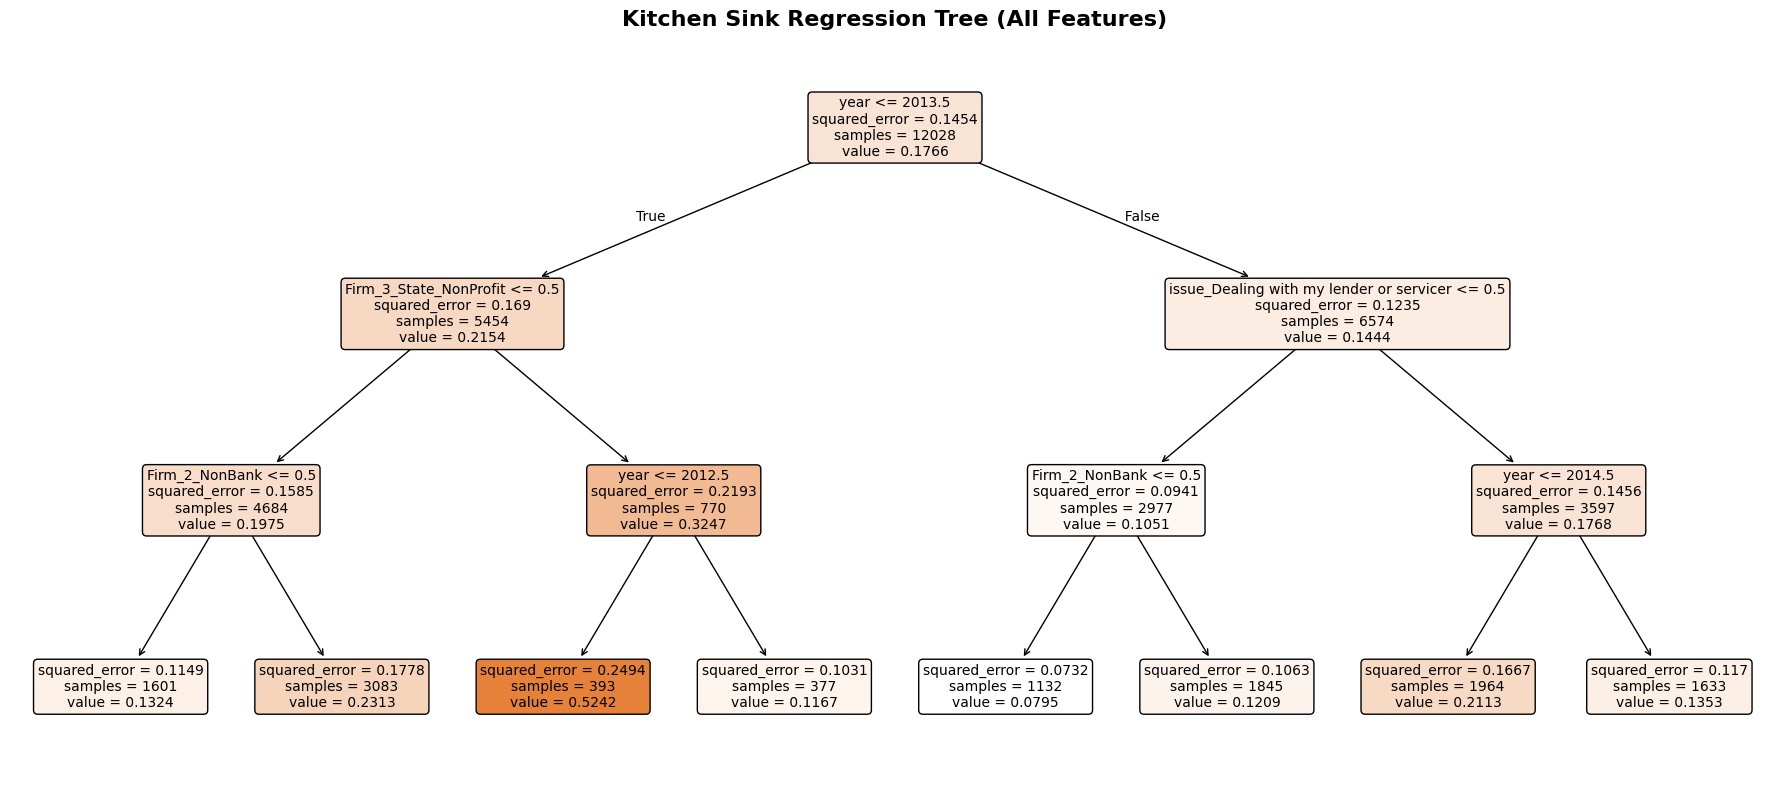


========== Part 7: Error of Prediction ==========
Mean Squared Error (MSE): 0.1385

Top Variables chosen in the Kitchen Sink Tree:
year                                        0.630503
Firm_2_NonBank                              0.138994
Firm_3_State_NonProfit                      0.129340
issue_Dealing with my lender or servicer    0.101163
dtype: float64


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

print("Starting Part 5: Kitchen Sink Regression Tree...")

# Prepare the data for the Kitchen Sink Tree by including all numeric features except those that are not meaningful for prediction or cause data leakage.
# Exclude:
exclude_cols = [
    # 1. Outcome variable
    'any_relief', 
    
    # 2. Variables that are direct components of the outcome or represent post-treatment information (to avoid data leakage)
    'company_response_to_consumer', 'monetary_relief', 'nonmonetary_relief', 
    'no_relief', 'explanation_only', 'timely_response', 'consumer_disputed?',
    
    # 3. Meaningless identifiers and dates (these won't help the tree learn generalizable patterns and can cause overfitting)
    'complaint_id', 'date_received', 'date_sent_to_company', 'zipcode',
    
    # 4. Textual and categorical variables that are not encoded as numeric (the tree can't use raw text or unencoded categories, and including them would require additional preprocessing)
    'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 
    'company', 'state', 'tags', 'submitted_via', 'Firm_Type',
    
    # 5. Data with %
    'Median Household Income', 'Poverty Rate (%)', 'Unemployment Rate (%)', "Bachelor's Degree or Higher (%)"
] 
# Include all other numeric features as potential predictors
kitchen_sink_features = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

# Drop rows with missing values
ks_df = df.dropna(subset=kitchen_sink_features + ['any_relief']).copy()

X_ks = ks_df[kitchen_sink_features]
y_ks = ks_df['any_relief']

print(f"Training Kitchen Sink Tree with {len(kitchen_sink_features)} features and {len(X_ks)} observations...")

# 2. Train the Decision Tree Regressor with the same constraints as before to maintain interpretability
ks_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=300, random_state=42)
ks_tree.fit(X_ks, y_ks)

# 3. Visualize the Kitchen Sink Tree with enhanced aesthetics
plt.figure(figsize=(18, 8))
plot_tree(
    ks_tree, 
    feature_names=kitchen_sink_features, 
    filled=True, 
    rounded=True, 
    fontsize=10,
    precision=4,
    proportion=False
)
plt.title("Kitchen Sink Regression Tree (All Features)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Kitchen_Sink_Tree.png", dpi=300)
plt.show()

# 4. Calculate and print the Mean Squared Error (MSE) of the predictions from the Kitchen Sink Tree to evaluate its performance
ks_predictions = ks_tree.predict(X_ks)
ks_mse = mean_squared_error(y_ks, ks_predictions)
print(f"\n========== Part 7: Error of Prediction ==========")
print(f"Mean Squared Error (MSE): {ks_mse:.4f}")
print("=================================================")

# Print the top features used in the Kitchen Sink Tree based on feature importance scores
print("\nTop Variables chosen in the Kitchen Sink Tree:")
ks_importances = pd.Series(ks_tree.feature_importances_, index=kitchen_sink_features)
print(ks_importances[ks_importances > 0].sort_values(ascending=False).head(5))

### Interpretation of Kitchen Sink Regression Tree Results
In the preferred specification tree, all four socioeconomic variables (log income, poverty rate, unemployment rate, and bachelor's degree share) have zero feature importance. This means that when the tree allocates its limited splitting power among all included variables, institutional factors such as firm type and issue type dominate so completely that socioeconomic characteristics are never selected. This contrasts with the OLS results, where unemployment is consistently negative and significant. The difference reflects the nature of the two methods: OLS estimates marginal effects holding all else constant, while the tree selects variables based on their unconditional ability to reduce prediction error. The implication is that socioeconomic disparities, while statistically detectable on average, are too small in magnitude to drive meaningful splits relative to institutional factors.

The kitchen sink tree confirms and extends this finding. When all available numeric features are included, the tree allocates its importance almost entirely to year (63%), firm type (26%), and issue type (10%). Socioeconomic variables are again excluded from all splits. The dominance of year likely reflects structural shifts in the student loan market over the 2012 to 2016 period, such as changes in CFPB enforcement intensity or evolving servicer practices. The later splits on firm type and issue type suggest that the type of institution a borrower complains against and the nature of the complaint create additional layers that shape outcomes more than individual borrower characteristics.

The kitchen sink tree has a Mean Squared Error of 0.1385. Since our dependent variable is binary, this is equivalent to the Brier Score. While the tree captures important institutional patterns, a large part of the variation remains unexplained, which is expected in micro-level complaint data where individual case details and unobserved factors play a significant role.

## 3.6 Random Forest

Starting Part 8: Random Forest Model...
Training 100 trees... This might take a few seconds...
Random Forest training complete!

========== Part 8: Random Forest Importance Matrix (Top 10) ==========
                                       Feature  Importance
0                                         year    0.357015
18                      Firm_3_State_NonProfit    0.127064
17                              Firm_2_NonBank    0.118901
16                               Bachelor_Rate    0.076095
5                                   log_income    0.057637
14                           Unemployment_Rate    0.047816
13                  issue_Repaying your loan.1    0.047330
15                                Poverty_Rate    0.043975
10  issue_Dealing with my lender or servicer.1    0.032270
4                     issue_Repaying your loan    0.029852


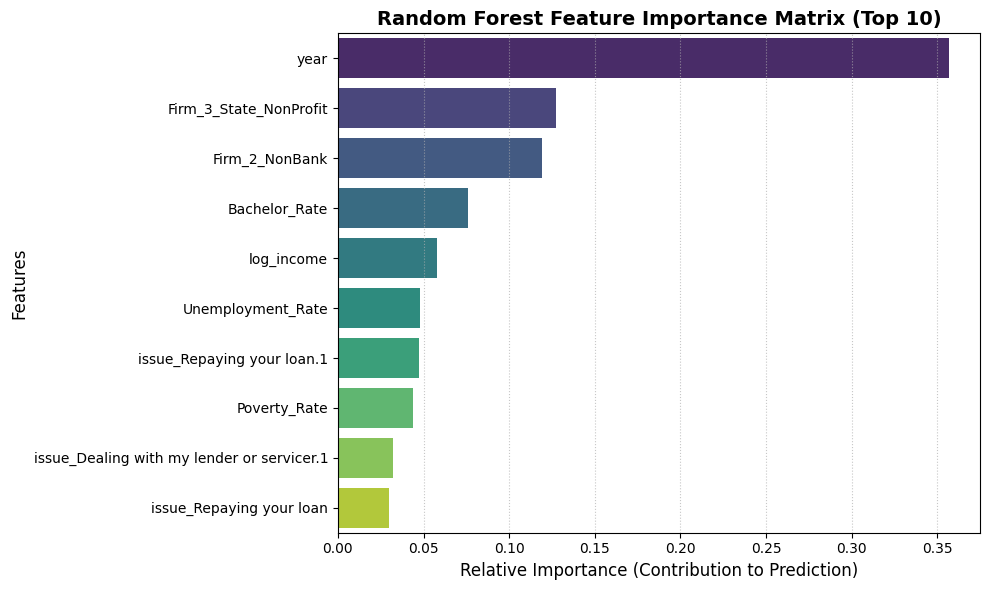

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor

print("Starting Part 8: Random Forest Model...")

# 1. Train a Random Forest Regressor using the same kitchen sink features to get a more robust estimate of feature importance. We will use the same constraints on tree depth and minimum samples to maintain interpretability while leveraging the ensemble's ability to capture complex patterns.
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=5, 
    min_samples_leaf=50, 
    random_state=42
)

print("Training 100 trees... This might take a few seconds...")
rf_model.fit(X_ks, y_ks) 
print("Random Forest training complete!\n")

# 2. Print the feature importance matrix from the Random Forest model, sorted by importance, to identify which features are most influential in predicting the probability of receiving relief.
importance_matrix = pd.DataFrame({
    'Feature': kitchen_sink_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("========== Part 8: Random Forest Importance Matrix (Top 10) ==========")
# Print only the top 10 features for better readability
print(importance_matrix.head(10))
print("======================================================================")

# 3. Draw a bar plot of the top 10 most important features from the Random Forest model to visually highlight which variables are driving the predictions. We will use a visually appealing color palette and add titles and labels for clarity.
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_matrix.head(10),
    hue='Feature',  
    palette='viridis',
    legend=False       
)
plt.title('Random Forest Feature Importance Matrix (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Contribution to Prediction)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()

# Save the plot with high resolution
plt.savefig('Random_Forest_Importance.png', dpi=300)
plt.show()

### Random Forest Model and Importance Matrix Interpretation

After training a Random Forest with 100 trees, the feature importance results provide a more detailed picture of what is associated with outcomes in the consumer finance market. Macroeconomic and institutional variables still appear to play a dominant role: "Year" is the most important feature (35.7%), followed by firm type (State/Non-Profit at 12.7% and Non-Bank at 11.8%). The dominance of year likely reflects structural shifts in the private student loan market over this period, potentially including changes in CFPB enforcement intensity, evolving complaint processing practices, or compositional changes in the servicer landscape. These time-varying factors would produce systematic year-to-year variation in relief rates that the model captures through the year variable, rather than through any single firm or borrower characteristic.

An interesting pattern is that demographic and socioeconomic variables become more visible in the Random Forest results. In a single decision tree, these variables were largely overshadowed by “Year” and “Firm Type.” However, because Random Forest restricts the set of features available to each tree, it allows other variables to be evaluated more consistently. As a result, variables such as Bachelor Rate (7.6%), log income (5.7%), unemployment (4.8%), and poverty (4.4%) show non-negligible importance. 

These results help bridge the gap between the machine learning model and the earlier OLS analysis. They suggest a layered structure: macro-level and institutional factors appear to play a dominant role in predicting outcomes, while socioeconomic characteristics also contribute in a consistent but secondary way. In other words, institutional factors seem to shape the overall environment, while individual characteristics may influence how outcomes vary within that environment.

At the end, it is important to note that these findings should be interpreted as predictive patterns rather than causal relationships.

## 3.7 OLS vs ML

The OLS regression and the regression tree provide complementary insights. OLS estimates constant marginal effects across the entire sample, allowing us to test whether socioeconomic variables are statistically significant predictors of relief outcomes on average. Our preferred specification shows that unemployment is consistently negative and significant, and that income is positively associated with non-monetary relief. These results confirm the existence of socioeconomic inequality in complaint outcomes.

However, OLS cannot reveal how the importance of these variables compares to institutional factors, nor can it capture non-linear or conditional relationships. The regression tree addresses this limitation. By selecting splitting variables based on their ability to reduce prediction error, the tree reveals that institutional factors such as firm type, issue type, and year dominate the prediction of relief outcomes. Socioeconomic variables were never selected as splitting criteria in the preferred specification tree, suggesting that their effects, while statistically detectable in OLS, are too small in magnitude to drive meaningful partitions relative to institutional factors.

The Random Forest further supports this interpretation. While institutional variables remain the most important predictors, socioeconomic variables such as bachelor's degree share, log income, and poverty rate appear with non-negligible importance when the model is allowed to evaluate features more broadly across many trees.

In summary, OLS identifies that socioeconomic inequality exists on average, while the ML models reveal that this inequality operates within a system where institutional and temporal factors play a larger role in determining outcomes. The two approaches together provide a more complete picture than either method alone.

## 3.8 Conclusion

This paper examines socioeconomic disparities in complaint resolution outcomes in the private student loan market, combining OLS regression with machine learning methods and exploratory NLP techniques. Using over 12,000 complaints from the CFPB merged with zip code-level ACS demographic data, we find that borrowers from higher-income and higher-education areas are more likely to receive financial relief, and this pattern persists after controlling for complaint type, firm type, and year.

Our OLS results show that socioeconomic inequality exists in complaint outcomes, particularly through the unemployment and income channels. However, the machine learning models reveal that institutional and temporal factors such as firm type, issue type, and year are far more important in predicting relief outcomes than individual socioeconomic characteristics. The Random Forest results help bridge these two findings by showing that socioeconomic variables, while secondary, still contribute consistently to prediction when evaluated across many trees.

Our exploratory NLP analysis of firm Terms of Service documents shows that most TOS texts require a college-level reading ability, suggesting that contractual complexity may create meaningful barriers for consumers from less-educated backgrounds.

Several directions remain for future work. First, the TOS readability scores could be merged with complaint-level data by company and year to test whether firms with more complex contracts exhibit larger socioeconomic gaps in relief, for instance through an interaction term between Flesch-Kincaid Grade and bachelor's degree share. Second, future research could apply readability or sentiment analysis directly to CFPB complaint narratives to test whether lower-SES borrowers systematically produce lower-quality complaints, providing a more direct test of the borrower sophistication channel than the zip code-level proxies used here.

# References


Best, A. L., & Andreasen, A. R. (1977). Consumer response to unsatisfactory purchases: A survey of complaining behavior. *Journal of Consumer Affairs*, 11(2), 88–102.

Bohren, J. A., Imas, A., & Rosenberg, M. (2019). The dynamics of discrimination: Theory and evidence. *American Economic Review*, 109(10), 3395–3436.

Darolia, R., & Sullivan, J. X. (2020). The economics of student loan repayment. *Annual Review of Economics*, 12, 453–475.

Haendler, C., & Heimer, R. (2021). The financial restitution gap in consumer finance: Insights from complaints filed with the CFPB. *Available at SSRN 3766485*.

Haendler, C., & Heimer, R. (2025). The Hidden Costs of Financial Services: Consumer Complaints and Financial Restitution. *Available at SSRN*.

Hastings, J. S., Madrian, B. C., & Skimmyhorn, W. L. (2013). Financial literacy, financial education, and economic outcomes. *Annual Review of Economics*, 5, 347–373.

Hirschman, A. O. (1972). *Exit, voice, and loyalty: Responses to decline in firms, organizations, and states*. Harvard University Press.

Kim, Y. S., Lee, D., Scharlemann, T., & Vickery, J. (2024). Intermediation frictions in debt relief: evidence from cares act forbearance. *Journal of Financial Economics*, 158, 103873.

Li, X. (2023). Does the disclosure of consumer complaints reduce racial disparities in the mortgage lending market. *Available at SSRN 4741819*.

Looney, A., & Yannelis, C. (2015). A crisis in student loans? How changes in the characteristics of borrowers and in the institutions they attended contributed to rising loan defaults. *Brookings Papers on Economic Activity*, 2015(2), 1–89.

Lusardi, A., & Mitchell, O. S. (2014). The economic importance of financial literacy: Theory and evidence. *Journal of Economic Literature*, 52(1), 5–44.

Mueller, H. M., & Yannelis, C. (2019). The rise in student loan defaults. *Journal of Financial Economics*, 131(1), 1–19.

Phelps, E. S. (1972). The statistical theory of racism and sexism. *American Economic Review*, 62(4), 659–661.

Shin, M., Kim, J., & Shin, J. (2026). The adoption and efficacy of large language models in US consumer financial complaints. *Nature Human Behaviour*, 1-12.